In [2]:
# Cell 1A: imports and paths

import pandas as pd
import numpy as np
from pathlib import Path
from scipy import stats
from scipy.optimize import minimize
import matplotlib.pyplot as plt

PROJ_ROOT = Path("~").expanduser() / "Desktop" / "shockley_repo"
DATA = PROJ_ROOT / "data"
FIGURES = PROJ_ROOT / "figures" / "figures_Hurdle" / "figures_Hurdle_AR1_GRW_P_SE"
RESULTS = PROJ_ROOT / "results" / "results_Hurdle" / "results_Hurdle_AR1_GRW_P_SE"

FIGURES.mkdir(parents=True, exist_ok=True)
RESULTS.mkdir(parents=True, exist_ok=True)

MODEL_NAME = "Hurdle-AR(1)-GRW-P-SE"
MODEL_TAG = "hurdle_ar1_grw_p_se"


In [3]:
# Cell 1B: analysis settings

EPS = 0.49
N = 1000
Y = 20
SEED = 63

MIN_PROB = 1e-6
MAX_PROB = 1 - 1e-6
MIN_POS_Q = 1e-12

SCHOLAR_EFFECT_DRAW_MODE = "normal"   # "normal" or "empirical"

rng = np.random.default_rng(SEED)

stage_spans = [
    (0, 4,  "0.70", "0-4"),
    (5, 7,  "0.78", "5-7"),
    (8, 13, "0.86", "8-13"),
    (14, 20,"0.93", "14-20")]


In [4]:
# Cell 1C: load data

df_original = pd.read_csv(DATA / "adjusted_productivity.csv")

# print(df_original.shape)
# df_original.head()


In [5]:
# Cell 4: build empirical panel

df_original['dblp_id'] = df_original['dblp'] + df_original['phd_year'].astype(str)
working_df = (df_original.sort_values(["dblp_id", "CareerAge"]).copy())

working_df["log_pubs_adj"] = np.log(working_df["pubs_adj"] + EPS)
working_df["is_active"] = (working_df["pubs_adj"] > 0).astype(int)

working_df["pubs_adj_next"] = working_df.groupby("dblp_id")["pubs_adj"].shift(-1)
working_df["CareerAge_next"] = working_df.groupby("dblp_id")["CareerAge"].shift(-1)
working_df["log_pubs_next"] = working_df.groupby("dblp_id")["log_pubs_adj"].shift(-1)
working_df["is_active_next"] = working_df.groupby("dblp_id")["is_active"].shift(-1)

working_df["log_delta"] = working_df["log_pubs_next"] - working_df["log_pubs_adj"]

is_next_year = working_df["CareerAge_next"].eq(working_df["CareerAge"] + 1)
is_in_window = working_df["CareerAge"].between(0, Y - 1)

working_df_fit = (working_df[is_next_year & is_in_window].dropna(subset=["pubs_adj", "pubs_adj_next", "is_active", "is_active_next"]).copy())

# print("Rows in orig:", len(working_df))
# print("Rows w/ ok 1yr trans:", len(working_df_fit))
# print()
# print(working_df_fit[["pubs_adj", "pubs_adj_next", "log_pubs_adj", "log_pubs_next", "log_delta"]].describe())


In [6]:
# Cell 3: career stages

stage_order = ["0-4", "5-7", "8-13", "14-20"]

def assign_career_stage(year):
    if 0 <= year <= 4:
        return "0-4"
    elif 5 <= year <= 7:
        return "5-7"
    elif 8 <= year <= 13:
        return "8-13"
    elif 14 <= year <= 20:
        return "14-20"
    else:
        return np.nan

working_df["career_stage"] = working_df["CareerAge"].apply(assign_career_stage)
working_df_fit["career_stage"] = working_df_fit["CareerAge"].apply(assign_career_stage)

# print("Prod obs by stage:")
# print(working_df["career_stage"].value_counts().reindex(stage_order))
# print()
# print("Trans obs by starting-year stage:")
# print(working_df_fit["career_stage"].value_counts().reindex(stage_order))


In [7]:
# Cell 4: build binary states and transition data

id_col = "dblp_id"
age_col = "CareerAge"
prod_col = "pubs_adj"

state_labels = {
    0: "No pubs",
    1: "Some pubs",}

state_order = [0, 1]
n_states = len(state_order)

df = working_df[working_df[age_col].between(0, Y)].copy()
df["state"] = (df[prod_col] > 0).astype(int)

trans = working_df_fit.copy()
trans["state"] = trans["is_active"].astype(int)
trans["next_state"] = trans["is_active_next"].astype(int)

# print(df[[id_col, age_col, prod_col, "state"]].head())
# print()
# print("State counts:")
# print(df["state"].map(state_labels).value_counts())
# print()
# print("Transition counts by type:")
# print(pd.crosstab(trans["state"], trans["next_state"]).rename(index=state_labels, columns=state_labels))


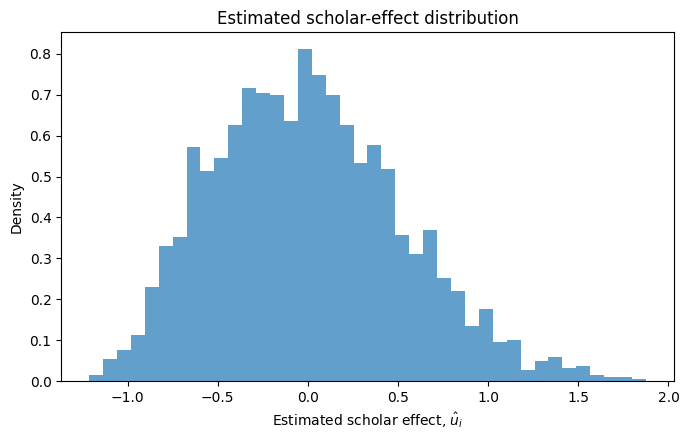

In [8]:
# Cell 5C: estimate scholar effects

scholar_effect_source = df.loc[
    (df["state"] == 1) &
    (df[prod_col] > 0) &
    df[age_col].between(0, Y),
    [id_col, age_col, prod_col]
].copy()

scholar_effect_source["log_q_pos"] = np.log(scholar_effect_source[prod_col])
year_log_means = scholar_effect_source.groupby(age_col)["log_q_pos"].mean()
scholar_effect_source["year_mean_log_q"] = scholar_effect_source[age_col].map(year_log_means)
scholar_effect_source["centered_log_q"] = scholar_effect_source["log_q_pos"] - scholar_effect_source["year_mean_log_q"]

scholar_effect_raw = (
    scholar_effect_source
    .groupby(id_col)
    .agg(
        n_pos_years=("centered_log_q", "size"),
        mean_centered_log_q=("centered_log_q", "mean"),
        sd_centered_log_q=("centered_log_q", "std"))
    .reset_index())

se_with_means = scholar_effect_source.merge(
    scholar_effect_raw[[id_col, "mean_centered_log_q"]],
    on=id_col,
    how="left")

within_resid = se_with_means["centered_log_q"] - se_with_means["mean_centered_log_q"]
sigma_within2 = float(np.nanmean(within_resid.to_numpy(dtype=float) ** 2))
raw_mean_var = float(scholar_effect_raw["mean_centered_log_q"].var(ddof=0))
mean_noise_var = float(np.mean(sigma_within2 / scholar_effect_raw["n_pos_years"].clip(lower=1)))
tau_scholar2 = max(raw_mean_var - mean_noise_var, 1e-8)
tau_scholar = float(np.sqrt(tau_scholar2))

scholar_effect_raw["shrinkage"] = (
    tau_scholar2 /
    (tau_scholar2 + sigma_within2 / scholar_effect_raw["n_pos_years"].clip(lower=1))
)

scholar_effect_raw["scholar_effect"] = scholar_effect_raw["shrinkage"] * scholar_effect_raw["mean_centered_log_q"]
scholar_effect_raw["scholar_effect"] = scholar_effect_raw["scholar_effect"] - scholar_effect_raw["scholar_effect"].mean()

scholar_effect_sd_empirical = float(scholar_effect_raw["scholar_effect"].std(ddof=0))
if not np.isfinite(scholar_effect_sd_empirical) or scholar_effect_sd_empirical <= 0:
    scholar_effect_sd_empirical = tau_scholar

scholar_effect_df = scholar_effect_raw[[
    id_col,
    "n_pos_years",
    "mean_centered_log_q",
    "shrinkage",
    "scholar_effect"
]].copy()

scholar_effect_summary = pd.DataFrame([{
    "n_scholars_with_positive_years": len(scholar_effect_df),
    "sigma_within2_centered_log_q": sigma_within2,
    "raw_var_scholar_mean_centered_log_q": raw_mean_var,
    "mean_noise_var": mean_noise_var,
    "tau_scholar2_mom": tau_scholar2,
    "tau_scholar_mom": tau_scholar,
    "sd_shrunk_scholar_effect": scholar_effect_sd_empirical,
    "mean_shrinkage": scholar_effect_df["shrinkage"].mean(),
    "median_shrinkage": scholar_effect_df["shrinkage"].median()}])

def add_scholar_effect(d):
    d = d.drop(columns=["scholar_effect"], errors="ignore")
    d = d.merge(scholar_effect_df[[id_col, "scholar_effect"]], on=id_col, how="left")
    d["scholar_effect"] = d["scholar_effect"].fillna(0.0)
    return d

df = add_scholar_effect(df)
trans = add_scholar_effect(trans)
working_df = add_scholar_effect(working_df)
working_df_fit = add_scholar_effect(working_df_fit)

# print("latent scholar effect, shrunk from centered positive log productivity")
# display(scholar_effect_summary.round(4))
# print("scholar effect quantiles")
# display(scholar_effect_df["scholar_effect"].quantile([0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]).to_frame("u_hat").round(4))

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(scholar_effect_df["scholar_effect"], bins=40, density=True, alpha=0.70)
ax.set_xlabel(r"Estimated scholar effect, $\hat u_i$")
ax.set_ylabel("Density")
ax.set_title("Estimated scholar-effect distribution")
plt.tight_layout()
plt.savefig(FIGURES / f"{MODEL_TAG}_scholarEffectDistribution.png", dpi=300, bbox_inches="tight")
plt.show()


In [9]:
# Cell 5A: yearwise binary transition matrices

def transition_counts_and_probs(g):
    counts = pd.crosstab(g["state"], g["next_state"])
    counts = counts.reindex(index=state_order, columns=state_order, fill_value=0)
    probs = counts.div(counts.sum(axis=1).replace(0, np.nan), axis=0)
    return counts, probs

global_counts, global_P = transition_counts_and_probs(trans)

year_counts = {}
year_P = {}

year_transition_rows = []

for year in range(Y):
    g = trans[trans[age_col] == year]
    counts, probs = transition_counts_and_probs(g)

    probs = probs.combine_first(global_P)

    year_counts[year] = counts
    year_P[year] = probs

    year_transition_rows.append({
        "year": year,
        "n": int(counts.values.sum()),
        "P_nothing_to_nothing": probs.loc[0, 0],
        "P_nothing_to_something": probs.loc[0, 1],
        "P_something_to_nothing": probs.loc[1, 0],
        "P_something_to_something": probs.loc[1, 1],})

year_transition_summary = pd.DataFrame(year_transition_rows)

# print("Global transition probabilities:")
# print(global_P.rename(index=state_labels, columns=state_labels).round(3))
# print()
# print("Yearwise transition summary:")
# display(year_transition_summary.round(3))


In [10]:
# Cell 5B: stagewise binary transition summary

stage_counts = {}
stage_P = {}
stage_transition_rows = []

for stage in stage_order:
    g = trans[trans["career_stage"] == stage]
    counts, probs = transition_counts_and_probs(g)
    probs = probs.combine_first(global_P)

    stage_counts[stage] = counts
    stage_P[stage] = probs

    stage_transition_rows.append({
        "stage": stage,
        "n": int(counts.values.sum()),
        "P_nothing_to_nothing": probs.loc[0, 0],
        "P_nothing_to_something": probs.loc[0, 1],
        "P_something_to_nothing": probs.loc[1, 0],
        "P_something_to_something": probs.loc[1, 1],})

stage_transition_summary = pd.DataFrame(stage_transition_rows)

# display(stage_transition_summary.round(3))


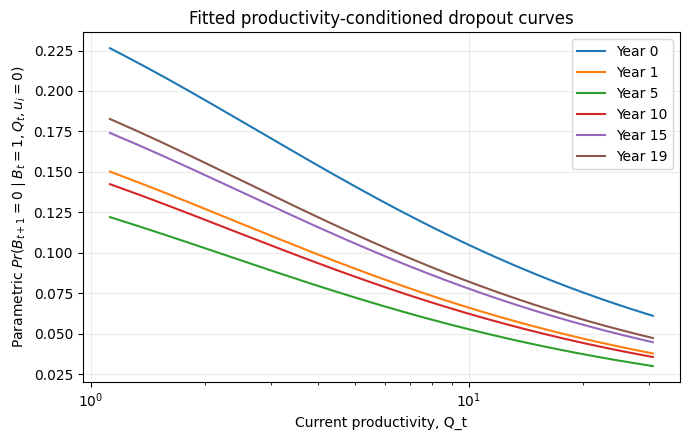

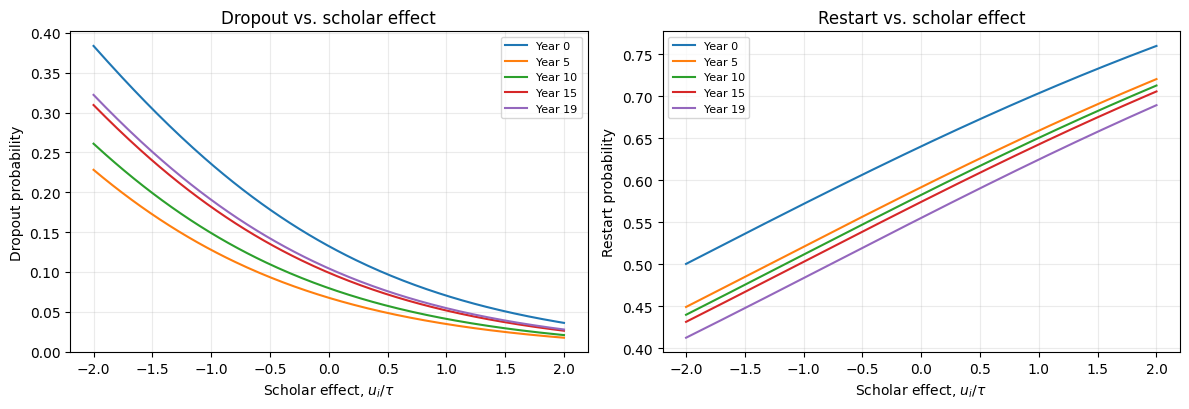

In [11]:
# Cell 6A: fit param prod-conditioned dropout + scholar-effect hurdle

def sigmoid_stable(x):
    x = np.clip(np.asarray(x, dtype=float), -35, 35)
    return 1 / (1 + np.exp(-x))

def logit_clipped(p):
    p = np.clip(p, MIN_PROB, MAX_PROB)
    return np.log(p / (1 - p))

init_active_fit = df.loc[df[age_col] == 0, [id_col, "state", "scholar_effect"]].copy()
init_y = init_active_fit["state"].astype(float).to_numpy()
init_u = init_active_fit["scholar_effect"].astype(float).to_numpy() / max(tau_scholar, 1e-8)
p_init_active = init_y.mean()

def init_active_nll(theta):
    intercept, scholar_coef = theta
    eta = intercept + scholar_coef * init_u
    p = sigmoid_stable(eta)
    return -np.sum(init_y * np.log(np.clip(p, MIN_PROB, MAX_PROB)) + (1 - init_y) * np.log(np.clip(1 - p, MIN_PROB, MAX_PROB)))

init_active_opt = minimize(
    init_active_nll,
    x0=np.array([logit_clipped(p_init_active), 0.0]),
    method="L-BFGS-B",
    bounds=[(-10, 10), (-10, 10)])

if not init_active_opt.success:
    print("WARNING: bad init-active converge")
    print(init_active_opt.message)

fitted_init_active_intercept = float(init_active_opt.x[0])
fitted_init_active_scholar_coef = float(init_active_opt.x[1])

def predict_init_active_prob(scholar_effect=0.0):
    u_arr = np.asarray(scholar_effect, dtype=float) / max(tau_scholar, 1e-8)
    eta = fitted_init_active_intercept + fitted_init_active_scholar_coef * u_arr
    out = np.clip(sigmoid_stable(eta), MIN_PROB, MAX_PROB)
    return float(out) if out.ndim == 0 else out

active_dropout_fit = trans.loc[
    (trans["state"] == 1) &
    trans["pubs_adj"].notna() &
    trans["next_state"].notna() &
    trans["CareerAge"].between(0, Y - 1),
    [id_col, "CareerAge", "pubs_adj", "next_state", "scholar_effect"]
].copy()

active_dropout_fit["drops_to_zero"] = (active_dropout_fit["next_state"] == 0).astype(int)
active_dropout_fit["log1p_q"] = np.log1p(active_dropout_fit["pubs_adj"].clip(lower=0))
active_dropout_fit["scholar_effect_scaled"] = active_dropout_fit["scholar_effect"] / max(tau_scholar, 1e-8)

year_idx = active_dropout_fit["CareerAge"].astype(int).to_numpy()
x_log1p_q = active_dropout_fit["log1p_q"].to_numpy(dtype=float)
x_scholar_effect_scaled = active_dropout_fit["scholar_effect_scaled"].to_numpy(dtype=float)
y_drop = active_dropout_fit["drops_to_zero"].to_numpy(dtype=float)

initial_intercepts = []
for year in range(Y):
    g = active_dropout_fit.loc[active_dropout_fit["CareerAge"] == year]
    raw_rate = g["drops_to_zero"].mean() if len(g) > 0 else y_drop.mean()
    initial_intercepts.append(logit_clipped(raw_rate))

initial_intercepts = np.asarray(initial_intercepts, dtype=float)
initial_log_gamma = np.log(0.25)
initial_dropout_scholar_coef = 0.0
initial_theta = np.r_[initial_intercepts, initial_log_gamma, initial_dropout_scholar_coef]

def dropout_neg_log_likelihood(theta):
    intercepts = theta[:Y]
    gamma = np.exp(theta[Y])
    scholar_coef = theta[Y + 1]

    eta = intercepts[year_idx] - gamma * x_log1p_q + scholar_coef * x_scholar_effect_scaled
    p_drop = sigmoid_stable(eta)

    nll = -np.sum(y_drop * np.log(np.clip(p_drop, MIN_PROB, MAX_PROB)) + (1 - y_drop) * np.log(np.clip(1 - p_drop, MIN_PROB, MAX_PROB)))
    return nll

bounds = [(-10, 10)] * Y + [(np.log(1e-6), np.log(25.0)), (-10, 10)]
opt = minimize(dropout_neg_log_likelihood, initial_theta, method="L-BFGS-B", bounds=bounds)

if not opt.success:
    print("WARNING: bad dropout converge")
    print(opt.message)

fitted_intercepts = opt.x[:Y]
fitted_gamma = float(np.exp(opt.x[Y]))
fitted_dropout_scholar_coef = float(opt.x[Y + 1])

def predict_dropout_prob(q, year, scholar_effect=0.0):
    q_arr, year_arr, u_arr = np.broadcast_arrays(
        np.asarray(q, dtype=float),
        np.asarray(year, dtype=int),
        np.asarray(scholar_effect, dtype=float))
    u_scaled = u_arr / max(tau_scholar, 1e-8)
    eta = fitted_intercepts[year_arr] - fitted_gamma * np.log1p(np.clip(q_arr, 0, None)) + fitted_dropout_scholar_coef * u_scaled
    out = np.clip(sigmoid_stable(eta), MIN_PROB, MAX_PROB)
    return float(out) if out.ndim == 0 else out

restart_fit = trans.loc[
    (trans["state"] == 0) &
    trans["next_state"].notna() &
    trans["CareerAge"].between(0, Y - 1),
    [id_col, "CareerAge", "next_state", "scholar_effect"]
].copy()

restart_fit["restarts"] = (restart_fit["next_state"] == 1).astype(int)
restart_fit["scholar_effect_scaled"] = restart_fit["scholar_effect"] / max(tau_scholar, 1e-8)

restart_year_idx = restart_fit["CareerAge"].astype(int).to_numpy()
x_restart_scholar_effect_scaled = restart_fit["scholar_effect_scaled"].to_numpy(dtype=float)
y_restart = restart_fit["restarts"].to_numpy(dtype=float)

restart_initial_intercepts = []
for year in range(Y):
    g = restart_fit.loc[restart_fit["CareerAge"] == year]
    raw_rate = g["restarts"].mean() if len(g) > 0 else y_restart.mean()
    restart_initial_intercepts.append(logit_clipped(raw_rate))

restart_initial_intercepts = np.asarray(restart_initial_intercepts, dtype=float)
restart_initial_scholar_coef = 0.0
restart_initial_theta = np.r_[restart_initial_intercepts, restart_initial_scholar_coef]

def restart_neg_log_likelihood(theta):
    intercepts = theta[:Y]
    scholar_coef = theta[Y]

    eta = intercepts[restart_year_idx] + scholar_coef * x_restart_scholar_effect_scaled
    p_restart = sigmoid_stable(eta)

    nll = -np.sum(y_restart * np.log(np.clip(p_restart, MIN_PROB, MAX_PROB)) + (1 - y_restart) * np.log(np.clip(1 - p_restart, MIN_PROB, MAX_PROB)))
    return nll

restart_bounds = [(-10, 10)] * Y + [(-10, 10)]
restart_opt = minimize(restart_neg_log_likelihood, restart_initial_theta, method="L-BFGS-B", bounds=restart_bounds)

if not restart_opt.success:
    print("WARNING: bad restart converge")
    print(restart_opt.message)

fitted_restart_intercepts = restart_opt.x[:Y]
fitted_restart_scholar_coef = float(restart_opt.x[Y])

def predict_restart_prob(year, scholar_effect=0.0):
    year_arr, u_arr = np.broadcast_arrays(np.asarray(year, dtype=int), np.asarray(scholar_effect, dtype=float))
    u_scaled = u_arr / max(tau_scholar, 1e-8)
    eta = fitted_restart_intercepts[year_arr] + fitted_restart_scholar_coef * u_scaled
    out = np.clip(sigmoid_stable(eta), MIN_PROB, MAX_PROB)
    return float(out) if out.ndim == 0 else out

restart_prob_by_year = np.array([predict_restart_prob(year, 0.0) for year in range(Y)])

q_ref = active_dropout_fit["pubs_adj"].quantile([0.25, 0.50, 0.75, 0.95]).to_dict()
u_low, u_mid, u_high = -tau_scholar, 0.0, tau_scholar

dropout_param_rows = []
for year in range(Y):
    g = active_dropout_fit.loc[active_dropout_fit["CareerAge"] == year]
    observed_dropout_rate = g["drops_to_zero"].mean() if len(g) > 0 else np.nan
    dropout_param_rows.append({
        "year": year,
        "n_active_transitions": len(g),
        "observed_dropout_rate": observed_dropout_rate,
        "restart_prob_if_zero_u_mid": restart_prob_by_year[year],
        "dropout_intercept": fitted_intercepts[year],
        "dropout_gamma_log1p_q": fitted_gamma,
        "dropout_scholar_coef_per_tau": fitted_dropout_scholar_coef,
        "pred_drop_q25_u_mid": predict_dropout_prob(q_ref[0.25], year, scholar_effect=u_mid),
        "pred_drop_q50_u_low": predict_dropout_prob(q_ref[0.50], year, scholar_effect=u_low),
        "pred_drop_q50_u_mid": predict_dropout_prob(q_ref[0.50], year, scholar_effect=u_mid),
        "pred_drop_q50_u_high": predict_dropout_prob(q_ref[0.50], year, scholar_effect=u_high),
        "pred_drop_q75_u_mid": predict_dropout_prob(q_ref[0.75], year, scholar_effect=u_mid),
        "pred_drop_q95_u_mid": predict_dropout_prob(q_ref[0.95], year, scholar_effect=u_mid)})

dropout_param_summary = pd.DataFrame(dropout_param_rows)

restart_param_rows = []
for year in range(Y):
    g = restart_fit.loc[restart_fit["CareerAge"] == year]
    observed_restart_rate = g["restarts"].mean() if len(g) > 0 else np.nan
    restart_param_rows.append({
        "year": year,
        "n_zero_transitions": len(g),
        "observed_restart_rate": observed_restart_rate,
        "restart_intercept": fitted_restart_intercepts[year],
        "restart_scholar_coef_per_tau": fitted_restart_scholar_coef,
        "pred_restart_u_low": predict_restart_prob(year, scholar_effect=u_low),
        "pred_restart_u_mid": predict_restart_prob(year, scholar_effect=u_mid),
        "pred_restart_u_high": predict_restart_prob(year, scholar_effect=u_high)})

restart_param_summary = pd.DataFrame(restart_param_rows)

# print("initial activity model with scholar effect")
# print(f"cnvg: {init_active_opt.success}")
# print(f"NLL: {init_active_opt.fun:.3f}")
# print(f"intercept: {fitted_init_active_intercept:.4f}")
# print(f"scholar coef per tau: {fitted_init_active_scholar_coef:.4f}")
# print()
# print("logistic dropout model: productivity + scholar effect")
# print(f"cnvg: {opt.success}")
# print(f"NLL: {opt.fun:.3f}")
# print(f"fit gamma on log(1 + Q_t): {fitted_gamma:.4f}")
# print(f"scholar coef per tau: {fitted_dropout_scholar_coef:.4f}")
# print()
# display(dropout_param_summary.round(4))
# print()
# print("restart model: year + scholar effect")
# print(f"cnvg: {restart_opt.success}")
# print(f"NLL: {restart_opt.fun:.3f}")
# print(f"scholar coef per tau: {fitted_restart_scholar_coef:.4f}")
# print()
# display(restart_param_summary.round(4))

q_grid = np.linspace(active_dropout_fit["pubs_adj"].quantile(0.01), active_dropout_fit["pubs_adj"].quantile(0.99), 300)
q_grid = np.clip(q_grid, MIN_POS_Q, None)

fig, ax = plt.subplots(figsize=(7, 4.5))
for year in [0, 1, 5, 10, 15, 19]:
    ax.plot(q_grid, predict_dropout_prob(q_grid, year, scholar_effect=0.0), label=f"Year {year}")

ax.set_xscale("log")
ax.set_xlabel("Current productivity, Q_t")
ax.set_ylabel(r"Parametric $Pr(B_{t+1}=0 \mid B_t=1, Q_t, u_i=0)$")
ax.set_title("Fitted productivity-conditioned dropout curves")
ax.legend()
ax.grid(alpha=0.25)

plt.tight_layout()
fig.savefig(FIGURES / f"{MODEL_TAG}_dropoutCurves.png", dpi=300, bbox_inches="tight")
plt.show()

u_grid = np.linspace(-2 * tau_scholar, 2 * tau_scholar, 200)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

for year in [0, 5, 10, 15, 19]:
    axes[0].plot(u_grid / max(tau_scholar, 1e-8), predict_dropout_prob(q_ref[0.50], year, scholar_effect=u_grid), label=f"Year {year}")
    axes[1].plot(u_grid / max(tau_scholar, 1e-8), predict_restart_prob(year, scholar_effect=u_grid), label=f"Year {year}")

axes[0].set_xlabel(r"Scholar effect, $u_i / \tau$")
axes[0].set_ylabel("Dropout probability")
axes[0].set_title("Dropout vs. scholar effect")
axes[1].set_xlabel(r"Scholar effect, $u_i / \tau$")
axes[1].set_ylabel("Restart probability")
axes[1].set_title("Restart vs. scholar effect")
for ax in axes:
    ax.legend(fontsize=8)
    ax.grid(alpha=0.25)

plt.tight_layout()
fig.savefig(FIGURES / f"{MODEL_TAG}_scholarEffectCurves.png", dpi=300, bbox_inches="tight")
plt.show()


In [12]:
# Cell 6B: fit positive-only yearwise log AR(1) with scholar effect

positive_ar1_fit = working_df_fit[
    (working_df_fit["pubs_adj"] > 0) &
    (working_df_fit["pubs_adj_next"] > 0)
].copy()

positive_ar1_fit["log_pubs_pos"] = np.log(positive_ar1_fit["pubs_adj"])
positive_ar1_fit["log_pubs_pos_next"] = np.log(positive_ar1_fit["pubs_adj_next"])
positive_ar1_fit["scholar_effect_scaled"] = positive_ar1_fit["scholar_effect"] / max(tau_scholar, 1e-8)

x = positive_ar1_fit["log_pubs_pos"].to_numpy(dtype=float)
y = positive_ar1_fit["log_pubs_pos_next"].to_numpy(dtype=float)
u = positive_ar1_fit["scholar_effect_scaled"].to_numpy(dtype=float)
year = positive_ar1_fit["CareerAge"].astype(int).to_numpy()
rows = np.arange(len(positive_ar1_fit))

X = np.zeros((len(positive_ar1_fit), 2 * Y + 1))
X[rows, year] = 1
X[rows, Y + year] = x
X[:, -1] = u

coef = np.linalg.lstsq(X, y, rcond=None)[0]
y_hat = X @ coef
resid = y - y_hat

fitted_positive_ar1_scholar_coef = float(coef[-1])
global_sigma_resid = float(np.sqrt(np.mean(resid ** 2)))

year_ar1_rows = []
for t in range(Y):
    keep = year == t
    r = resid[keep]

    intercept = float(coef[t])
    beta = float(coef[Y + t])
    sigma = float(np.sqrt(np.mean(r ** 2))) if keep.sum() > 0 else global_sigma_resid
    var = sigma ** 2

    if abs(beta) < 1:
        implied_mean = (intercept + fitted_positive_ar1_scholar_coef * 0) / (1 - beta)
        implied_var = var / (1 - beta ** 2)
    else:
        implied_mean = np.nan
        implied_var = np.nan

    year_ar1_rows.append({
        "year": t,
        "n": int(keep.sum()),
        "intercept": intercept,
        "beta": beta,
        "scholar_coef_per_tau": fitted_positive_ar1_scholar_coef,
        "sigma_resid": sigma,
        "var_resid": var,
        "implied_stationary_mean_log_u0": implied_mean,
        "implied_stationary_var_log_u0": implied_var,
        "mean_resid": float(r.mean()) if keep.sum() else np.nan,
        "sd_resid": float(r.std(ddof=0)) if keep.sum() else np.nan})

year_ar1_params = pd.DataFrame(year_ar1_rows)

X_global = np.column_stack([np.ones(len(x)), x, u])
global_coef = np.linalg.lstsq(X_global, y, rcond=None)[0]
global_resid = y - X_global @ global_coef
global_beta = float(global_coef[1])
global_var = float(np.mean(global_resid ** 2))

global_ar1_params = pd.DataFrame([{
    "model": "global_positive_se",
    "n": len(x),
    "intercept": float(global_coef[0]),
    "beta": global_beta,
    "scholar_coef_per_tau": float(global_coef[2]),
    "sigma_resid": float(np.sqrt(global_var)),
    "var_resid": global_var,
    "implied_stationary_mean_log_u0": float(global_coef[0] / (1 - global_beta)) if abs(global_beta) < 1 else np.nan,
    "implied_stationary_var_log_u0": float(global_var / (1 - global_beta ** 2)) if abs(global_beta) < 1 else np.nan,
    "mean_resid": float(global_resid.mean()),
    "sd_resid": float(global_resid.std(ddof=0))}])

# print("Global positive-only AR(1) with scholar effect")
# display(global_ar1_params)

# print("Yearwise positive-only AR(1) with global scholar effect")
# display(year_ar1_params)

# print("problematic abs beta >= 1")
# display(year_ar1_params.loc[year_ar1_params["beta"].abs() >= 1])


In [13]:
# Cell 7A: fit init, restart exponentials

q0_empirical = working_df.loc[working_df["CareerAge"] == 0, "pubs_adj"].dropna()
q0_pos_empirical = q0_empirical[q0_empirical > 0]

alpha_q0_pos = q0_pos_empirical.mean()
lambda_q0_pos = 1 / alpha_q0_pos

restart_q_empirical = trans.loc[(trans["state"] == 0) & (trans["next_state"] == 1), "pubs_adj_next"].dropna()
restart_q_empirical = restart_q_empirical[restart_q_empirical > 0]

alpha_restart = restart_q_empirical.mean()
lambda_restart = 1 / alpha_restart

# print("raw init active pr:", p_init_active)
# print("init pos exp scale alpha:", alpha_q0_pos)
# print("init pos exp rate lambda:", lambda_q0_pos)
# print()
# print("Restart exp scale alpha:", alpha_restart)
# print("Restart exp rate lambda:", lambda_restart)
# print("emp restart n:", len(restart_q_empirical))
# print()
# print("Restart mag emp sum:")
# print(restart_q_empirical.describe())


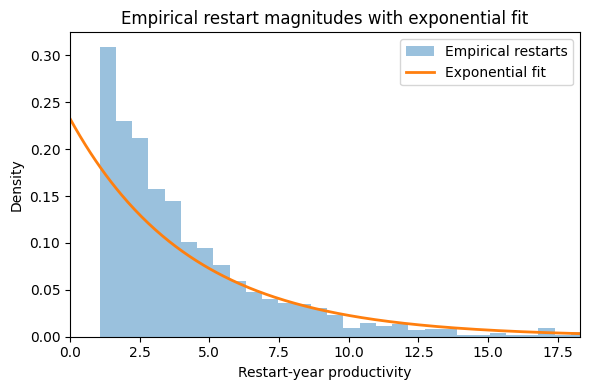

In [14]:
# Cell 7B: restart dx check

x_max = np.quantile(restart_q_empirical, 0.99)
x_grid = np.linspace(0, x_max, 300)
restart_pdf = lambda_restart * np.exp(-lambda_restart * x_grid)

fig, ax = plt.subplots(figsize=(6, 4))

ax.hist(restart_q_empirical,bins=50,density=True,alpha=0.45,label="Empirical restarts")

ax.plot(x_grid,restart_pdf,linewidth=2,label="Exponential fit")

ax.set_xlim(0, x_max)
ax.set_xlabel("Restart-year productivity")
ax.set_ylabel("Density")
ax.set_title("Empirical restart magnitudes with exponential fit")
ax.legend()

plt.tight_layout()
plt.savefig(FIGURES / f"{MODEL_TAG}_restartFit.png", dpi=300, bbox_inches="tight")
plt.show()


In [15]:
# Cell 8: simulation helpers

def make_ar1_year_lookup(year_ar1_params):
    return (
        year_ar1_params
        .set_index("year")[["intercept", "beta", "sigma_resid", "scholar_coef_per_tau"]]
        .to_dict("index"))

ar1_year_lookup = make_ar1_year_lookup(year_ar1_params)

def draw_exponential_positive(scale, size, rng):
    if size == 0:
        return np.array([], dtype=float)
    return np.clip(rng.exponential(scale=scale, size=size), MIN_POS_Q, None)

def draw_scholar_effects(n, rng):
    if SCHOLAR_EFFECT_DRAW_MODE == "empirical":
        return rng.choice(scholar_effect_df["scholar_effect"].to_numpy(dtype=float), size=n, replace=True)
    return rng.normal(loc=0, scale=tau_scholar, size=n)

def draw_next_binary_state_parametric(q_current, b_current, scholar_effect, year, rng):
    q_current = np.asarray(q_current, dtype=float)
    b_current = np.asarray(b_current, dtype=int)
    scholar_effect = np.asarray(scholar_effect, dtype=float)

    p_to_active = np.zeros(len(b_current), dtype=float)

    currently_zero = b_current == 0
    currently_active = b_current == 1

    if currently_zero.any():
        p_to_active[currently_zero] = predict_restart_prob(year, scholar_effect=scholar_effect[currently_zero])

    if currently_active.any():
        p_drop = predict_dropout_prob(q_current[currently_active], year, scholar_effect=scholar_effect[currently_active])
        p_to_active[currently_active] = 1 - p_drop

    p_to_active = np.clip(p_to_active, MIN_PROB, MAX_PROB)
    return rng.binomial(1, p_to_active, size=len(b_current)).astype(int)

def simulate_parametric_productivity_conditioned_hurdle_se(
    ar1_year_lookup,
    alpha_q0_pos=alpha_q0_pos,
    alpha_restart=alpha_restart,
    Y=Y,
    n=N,
    rng=None):

    if rng is None:
        rng = np.random.default_rng()

    trajectories = np.zeros((Y + 1, n), dtype=float)
    z_paths = np.full((Y + 1, n), np.nan, dtype=float)
    b_paths = np.zeros((Y + 1, n), dtype=int)
    scholar_effect = draw_scholar_effects(n, rng)

    p0 = predict_init_active_prob(scholar_effect)
    b_paths[0] = rng.binomial(1, p0, size=n).astype(int)

    init_active = b_paths[0] == 1
    q0 = np.zeros(n)
    q0[init_active] = draw_exponential_positive(alpha_q0_pos, init_active.sum(), rng)

    trajectories[0] = q0
    z_paths[0, init_active] = np.log(q0[init_active])

    for t in range(Y):
        q_now = trajectories[t]
        b_now = b_paths[t]

        b_next = draw_next_binary_state_parametric(
            q_current=q_now,
            b_current=b_now,
            scholar_effect=scholar_effect,
            year=t,
            rng=rng)

        q_next = np.zeros(n)
        z_next = np.full(n, np.nan)

        restart = (b_now == 0) & (b_next == 1)
        continued = (b_now == 1) & (b_next == 1)

        if restart.sum() > 0:
            q_restart = draw_exponential_positive(alpha_restart, restart.sum(), rng)
            q_next[restart] = q_restart
            z_next[restart] = np.log(q_restart)

        if continued.sum() > 0:
            intercept = ar1_year_lookup[t]["intercept"]
            beta = ar1_year_lookup[t]["beta"]
            sigma = ar1_year_lookup[t]["sigma_resid"]
            scholar_coef = ar1_year_lookup[t]["scholar_coef_per_tau"]
            u_scaled = scholar_effect[continued] / max(tau_scholar, 1e-8)

            shock = rng.normal(loc=0, scale=sigma, size=continued.sum())
            z_cont = intercept + beta * z_paths[t, continued] + scholar_coef * u_scaled + shock

            q_next[continued] = np.exp(z_cont)
            z_next[continued] = z_cont

        trajectories[t + 1] = q_next
        z_paths[t + 1] = z_next
        b_paths[t + 1] = b_next

    return trajectories, z_paths, b_paths, scholar_effect

def simulate_combined_model(ar1_year_lookup, n=N, Y=Y, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    return simulate_parametric_productivity_conditioned_hurdle_se(
        ar1_year_lookup=ar1_year_lookup,
        alpha_q0_pos=alpha_q0_pos,
        alpha_restart=alpha_restart,
        Y=Y,
        n=n,
        rng=rng)

def trajectories_to_dataframe_combined(trajs, b_paths, scholar_effects):
    years = np.arange(trajs.shape[0])
    ix = np.arange(trajs.shape[1])

    df_sim = pd.DataFrame({
        "CareerAge": np.repeat(years, len(ix)),
        "ix": np.tile(ix, len(years)),
        "pubs_adj": trajs.reshape(-1),
        "state": b_paths.reshape(-1),
        "scholar_effect": np.tile(scholar_effects, len(years))})

    df_sim["pubs_adj_next"] = df_sim.groupby("ix")["pubs_adj"].shift(-1)
    df_sim["state_next"] = df_sim.groupby("ix")["state"].shift(-1)
    df_sim["q_adj_delta"] = df_sim["pubs_adj_next"] - df_sim["pubs_adj"]
    df_sim["log_pubs_adj"] = np.where(df_sim["pubs_adj"] > 0, np.log(df_sim["pubs_adj"]), np.nan)
    df_sim["log_pubs_next"] = np.where(df_sim["pubs_adj_next"] > 0, np.log(df_sim["pubs_adj_next"]), np.nan)
    df_sim["log_delta"] = df_sim["log_pubs_next"] - df_sim["log_pubs_adj"]

    return df_sim.dropna(subset=["pubs_adj_next", "state_next"]).copy()


In [16]:
# Cell 9: simulate combined hurdle AR(1) w scholar effects

(
    trajs_combined,
    z_trajs_combined,
    b_trajs_combined,
    scholar_effects_simulated,
) = simulate_combined_model(
    ar1_year_lookup=ar1_year_lookup,
    n=N,
    Y=Y,
    rng=rng)

trajs = trajs_combined
b_trajs = b_trajs_combined

df_trajs = trajectories_to_dataframe_combined(trajs, b_trajs, scholar_effects_simulated)

# print("trajectory array shape:", trajs.shape)
# print("binary path array shape:", b_trajs.shape)
# print("simulated scholar effects shape:", scholar_effects_simulated.shape)
# print()
# print("sim'd state fractions:")
# for t in [0, 5, 10, 15, 20]:
#     print(f"Year {t}: zero={(b_trajs[t] == 0).mean():.4f}, active={(b_trajs[t] == 1).mean():.4f}")

# print()
# print("sim'd scholar-effect summary:")
# print(pd.Series(scholar_effects_simulated).describe())
# print()
# print("sim'd positive log increments:")
# print(df_trajs.loc[(df_trajs["state"] == 1) & (df_trajs["state_next"] == 1), "log_delta"].describe())


/Users/samlunemagid/miniconda3/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/samlunemagid/miniconda3/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


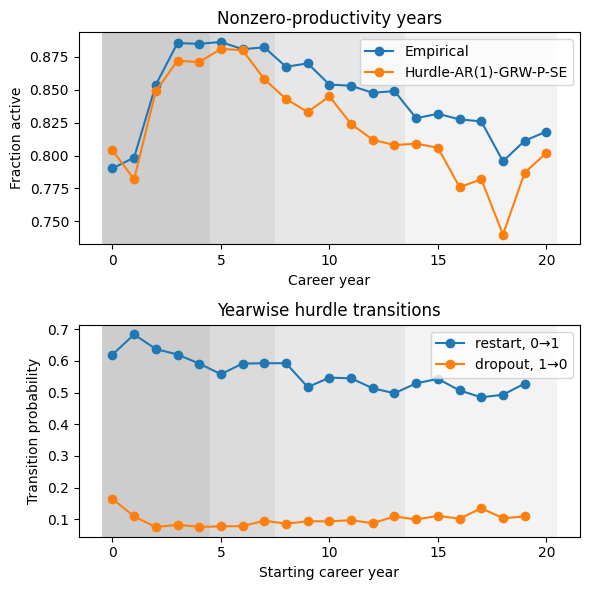

In [17]:
# Cell 10: binary path dx

emp_state_by_year = (df.groupby(age_col)["state"].agg(frac_active="mean",n="size").reset_index())

sim_state_by_year = pd.DataFrame({
    "year": np.arange(Y + 1),
    "frac_active": b_trajs_combined.mean(axis=1),
    "n": b_trajs_combined.shape[1],})

fig, axes = plt.subplots(2, 1, figsize=(6, 6))

for ax in axes:
    for start, end, shade, label in stage_spans:
        ax.axvspan(start - 0.5,end + 0.5,facecolor=shade,alpha=0.65,zorder=0)

axes[0].plot(emp_state_by_year["CareerAge"], emp_state_by_year["frac_active"], marker="o", label="Empirical", zorder = 3)
axes[0].plot(sim_state_by_year["year"], sim_state_by_year["frac_active"], marker="o", label=MODEL_NAME, zorder = 3)
axes[0].set_xlabel("Career year")
axes[0].set_ylabel("Fraction active")
axes[0].set_title("Nonzero-productivity years")
axes[0].legend()

axes[1].plot(year_transition_summary["year"], year_transition_summary["P_nothing_to_something"], marker="o", label="restart, 0→1", zorder = 3)
axes[1].plot(year_transition_summary["year"], year_transition_summary["P_something_to_nothing"], marker="o", label="dropout, 1→0", zorder = 3)
axes[1].set_xlabel("Starting career year")
axes[1].set_ylabel("Transition probability")
axes[1].set_title("Yearwise hurdle transitions")
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES / f"{MODEL_TAG}_Dx.png", dpi=300, bbox_inches="tight")
plt.show()


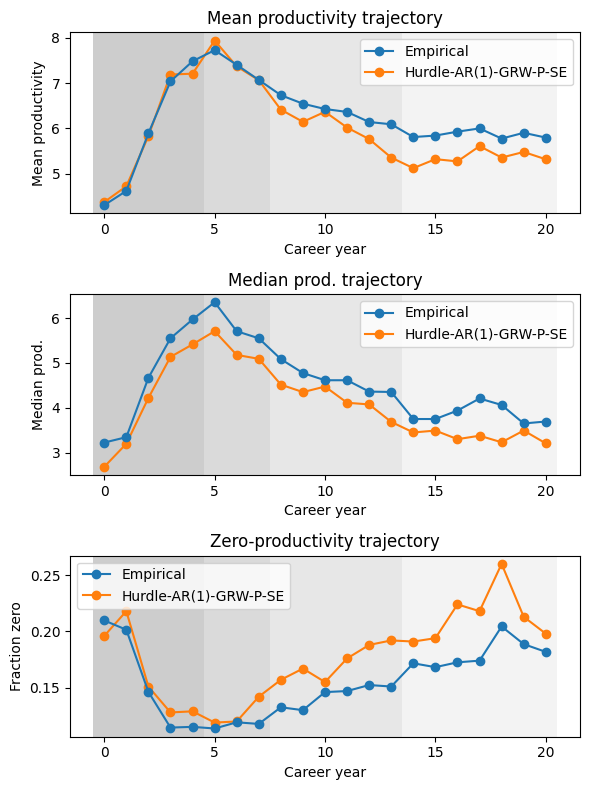

In [18]:
# Cell 11: canonical trajectory check

emp_mean = (working_df[working_df["CareerAge"].between(0, Y)].groupby("CareerAge")["pubs_adj"].mean())

emp_median = (working_df[working_df["CareerAge"].between(0, Y)].groupby("CareerAge")["pubs_adj"].median())

emp_frac_zero = (working_df[working_df["CareerAge"].between(0, Y)].groupby("CareerAge")["pubs_adj"].apply(lambda x: (x == 0).mean()))

sim_mean = trajs_combined.mean(axis=1)
sim_median = np.median(trajs_combined, axis=1)
sim_frac_zero = (trajs_combined == 0).mean(axis=1)

years = np.arange(Y + 1)

fig, axes = plt.subplots(3, 1, figsize=(6, 8))
for ax in axes:
    for start, end, shade, label in stage_spans:
        ax.axvspan(start - 0.5,end + 0.5,facecolor=shade,alpha=0.65,zorder=0)

axes[0].plot(emp_mean.index, emp_mean.values, marker="o", label="Empirical", zorder = 3)
axes[0].plot(years, sim_mean, marker="o", label=MODEL_NAME)
axes[0].set_xlabel("Career year")
axes[0].set_ylabel("Mean productivity")
axes[0].set_title("Mean productivity trajectory")
axes[0].legend()

axes[1].plot(emp_median.index, emp_median.values, marker="o", label="Empirical", zorder = 3)
axes[1].plot(years, sim_median, marker="o", label=MODEL_NAME)
axes[1].set_xlabel("Career year")
axes[1].set_ylabel("Median prod.")
axes[1].set_title("Median prod. trajectory")
axes[1].legend()

axes[2].plot(emp_frac_zero.index, emp_frac_zero.values, marker="o", label="Empirical", zorder = 3)
axes[2].plot(years, sim_frac_zero, marker="o", label=MODEL_NAME)
axes[2].set_xlabel("Career year")
axes[2].set_ylabel("Fraction zero")
axes[2].set_title("Zero-productivity trajectory")
axes[2].legend()

plt.tight_layout()

plt.savefig(FIGURES / f"{MODEL_TAG}_trajectories.png", dpi=300, bbox_inches="tight")

plt.show()


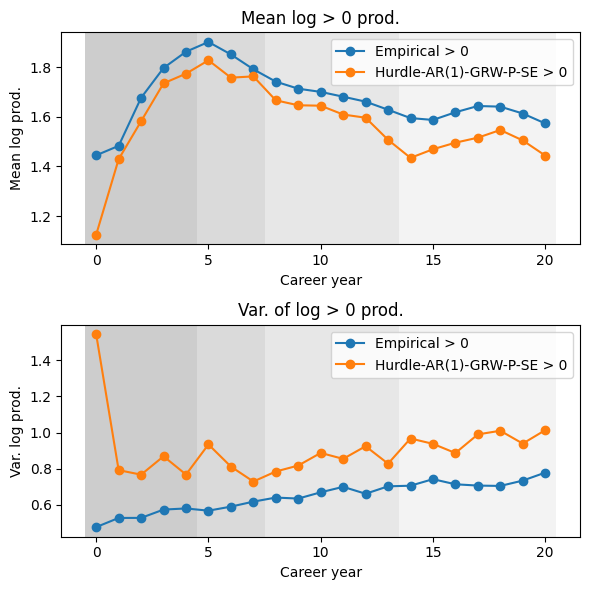

In [19]:
# Cell 12: yearwise log distrib dx

years = np.arange(0, Y + 1)

emp_year_stats = []
for t in years:
    subset = working_df[working_df["CareerAge"] == t]
    q = subset["pubs_adj"].dropna()

    q_pos = q[q > 0]
    log_q_pos = np.log(q_pos)

    emp_year_stats.append({
        "year": t,
        "n": len(q),
        "frac_zero": (q == 0).mean(),
        "mean_prod": q.mean(),
        "median_prod": q.median(),
        "mean_log_prod_pos": log_q_pos.mean(),
        "var_log_prod_pos": log_q_pos.var(ddof=0),
        "q25_prod": q.quantile(0.25),
        "q50_prod": q.quantile(0.50),
        "q75_prod": q.quantile(0.75),
        "q90_prod": q.quantile(0.90),
        "q95_prod": q.quantile(0.95)})

emp_year_stats = pd.DataFrame(emp_year_stats)

sim_year_stats = []
for t in years:
    q = pd.Series(trajs_combined[t])

    q_pos = q[q > 0]
    log_q_pos = np.log(q_pos)

    sim_year_stats.append({
        "year": t,
        "n": len(q),
        "frac_zero": (q == 0).mean(),
        "mean_prod": q.mean(),
        "median_prod": q.median(),
        "mean_log_prod_pos": log_q_pos.mean(),
        "var_log_prod_pos": log_q_pos.var(ddof=0),
        "q25_prod": q.quantile(0.25),
        "q50_prod": q.quantile(0.50),
        "q75_prod": q.quantile(0.75),
        "q90_prod": q.quantile(0.90),
        "q95_prod": q.quantile(0.95)})

sim_year_stats = pd.DataFrame(sim_year_stats)

fig, axes = plt.subplots(2, 1, figsize=(6, 6))
for ax in axes:
    for start, end, shade, label in stage_spans:
        ax.axvspan(start - 0.5,end + 0.5,facecolor=shade,alpha=0.65,zorder=0)
axes[0].plot(emp_year_stats["year"],emp_year_stats["mean_log_prod_pos"],marker="o",label="Empirical > 0", zorder = 3)
axes[0].plot(sim_year_stats["year"],sim_year_stats["mean_log_prod_pos"],marker="o",label=f"{MODEL_NAME} > 0", zorder = 3)
axes[0].set_title("Mean log > 0 prod.")
axes[0].set_xlabel("Career year")
axes[0].set_ylabel("Mean log prod.")
axes[0].legend()

axes[1].plot(emp_year_stats["year"],emp_year_stats["var_log_prod_pos"],marker="o",label="Empirical > 0", zorder = 3)
axes[1].plot(sim_year_stats["year"],sim_year_stats["var_log_prod_pos"],marker="o", label=f"{MODEL_NAME} > 0", zorder = 3)
axes[1].set_title("Var. of log > 0 prod.")
axes[1].set_xlabel("Career year")
axes[1].set_ylabel("Var. log prod.")
axes[1].legend()

plt.tight_layout()

plt.savefig(FIGURES / f"{MODEL_TAG}_posLog.png", dpi=300, bbox_inches="tight")
plt.show()


In [20]:
# Cell 13A: yearwise log-delta distrib dx func

def binned_mode(x, bins="auto"):
    x = pd.Series(x).dropna().to_numpy()

    if len(x) == 0:
        return np.nan

    if np.nanmin(x) == np.nanmax(x):
        return float(x[0])

    counts, edges = np.histogram(x, bins=bins)
    k = np.argmax(counts)

    return (edges[k] + edges[k + 1]) / 2

def make_log_delta_stats(df, year_col="CareerAge", delta_col="log_delta", Y=20):

    years = np.arange(0, Y)

    rows = []
    for t in years:
        subset = df[df[year_col] == t]
        dz = subset[delta_col].dropna()

        rows.append({
            "year": t,
            "n": len(dz),
            "mean_log_delta": dz.mean(),
            "median_log_delta": dz.median(),
            "mode_log_delta": binned_mode(dz),
            "var_log_delta": dz.var(ddof=0),
            "q25_log_delta": dz.quantile(0.25),
            "q50_log_delta": dz.quantile(0.50),
            "q75_log_delta": dz.quantile(0.75),
            "q90_log_delta": dz.quantile(0.90),
            "q95_log_delta": dz.quantile(0.95)})

    return pd.DataFrame(rows)


In [21]:
# Cell 13B: yearwise log delta stats get

emp_delta_stats = make_log_delta_stats(working_df_fit,year_col="CareerAge",delta_col="log_delta",Y=Y)

TRJ = np.asarray(trajs_combined)

if TRJ.shape[0] != Y + 1 and TRJ.shape[1] == Y + 1:
    TRJ = TRJ.T

assert TRJ.shape[0] == Y + 1, f"got {TRJ.shape}"

df_sim_delta = pd.DataFrame({"CareerAge": np.repeat(np.arange(Y), TRJ.shape[1]),"pubs_adj": TRJ[:-1, :].ravel(),"pubs_adj_next": TRJ[1:, :].ravel(),})

df_sim_delta["log_delta"] = (np.log(df_sim_delta["pubs_adj_next"] + EPS)- np.log(df_sim_delta["pubs_adj"] + EPS))

sim_delta_stats = make_log_delta_stats(df_sim_delta,year_col="CareerAge",delta_col="log_delta",Y=Y)


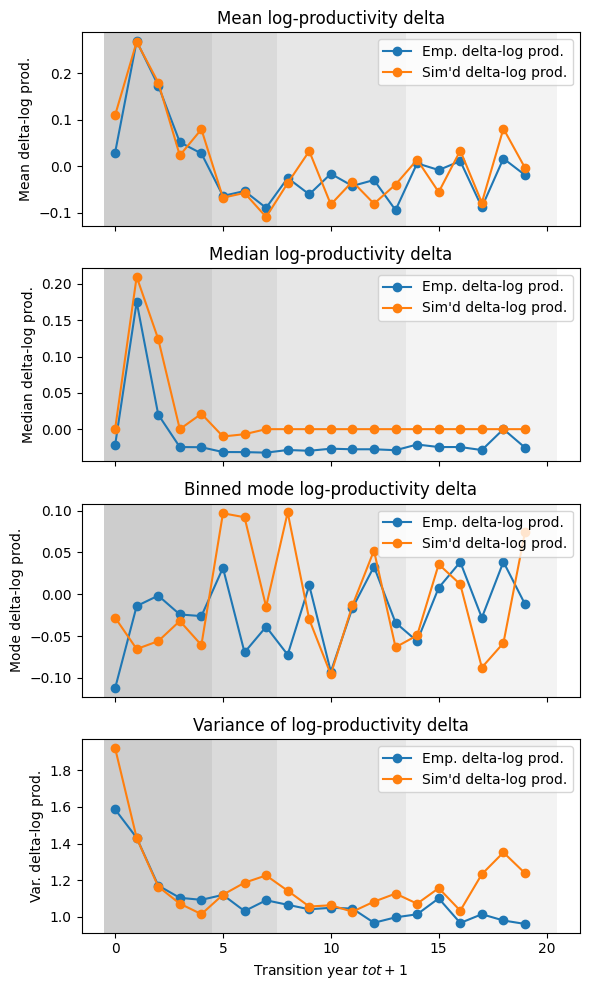

In [22]:
# Cell 13C: plot yearwise log-delta moments

fig, axes = plt.subplots(4, 1, figsize=(6, 10), sharex=True)

for ax in axes:
    for start, end, shade, label in stage_spans:
        ax.axvspan(start - 0.5,end + 0.5,facecolor=shade,alpha=0.65,zorder=0)


axes[0].plot(emp_delta_stats["year"],emp_delta_stats["mean_log_delta"],marker="o", label="Emp. delta-log prod.", zorder=3)
axes[0].plot(sim_delta_stats["year"],sim_delta_stats["mean_log_delta"],marker="o",label="Sim'd delta-log prod.", zorder=3)
axes[0].set_title("Mean log-productivity delta")
axes[0].set_ylabel("Mean delta-log prod.")
axes[0].legend()

axes[1].plot(emp_delta_stats["year"],emp_delta_stats["median_log_delta"],marker="o",label="Emp. delta-log prod.",zorder=3)
axes[1].plot(sim_delta_stats["year"],sim_delta_stats["median_log_delta"],marker="o",label="Sim'd delta-log prod.",zorder=3)
axes[1].set_title("Median log-productivity delta")
axes[1].set_ylabel("Median delta-log prod.")
axes[1].legend()

axes[2].plot(emp_delta_stats["year"],emp_delta_stats["mode_log_delta"],marker="o",label="Emp. delta-log prod.",zorder=3)
axes[2].plot(sim_delta_stats["year"],sim_delta_stats["mode_log_delta"],marker="o",label="Sim'd delta-log prod.",zorder=3)
axes[2].set_title("Binned mode log-productivity delta")
axes[2].set_ylabel("Mode delta-log prod.")
axes[2].legend()

axes[3].plot(emp_delta_stats["year"],emp_delta_stats["var_log_delta"],marker="o",label="Emp. delta-log prod.", zorder=3)
axes[3].plot(sim_delta_stats["year"],sim_delta_stats["var_log_delta"],marker="o",label="Sim'd delta-log prod.",zorder=3)
axes[3].set_title("Variance of log-productivity delta")
axes[3].set_xlabel("Transition year $t \to t+1$")
axes[3].set_ylabel("Var. delta-log prod.")
axes[3].legend()

plt.tight_layout()

plt.savefig(FIGURES / f"{MODEL_TAG}_logDeltaMoments.png",dpi=300,bbox_inches="tight")
plt.show()


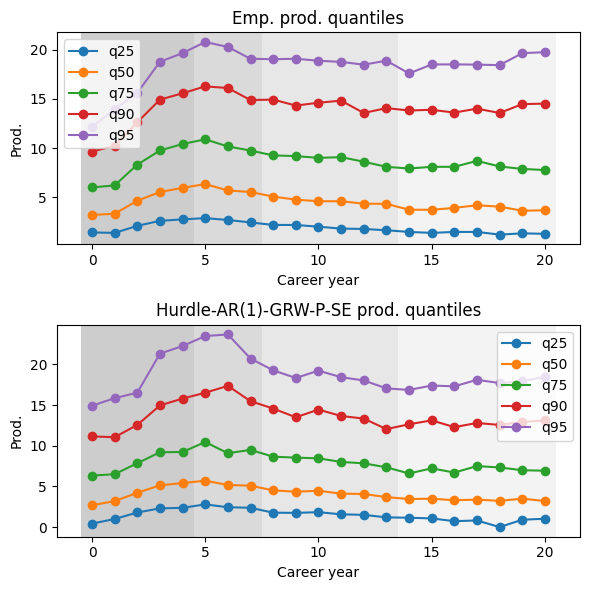

In [23]:
# Cell 14: yearwise quantile distrib dx

qcols = ["q25_prod", "q50_prod", "q75_prod", "q90_prod", "q95_prod"]

fig, axes = plt.subplots(2, 1, figsize=(6, 6))
for ax in axes:
    for start, end, shade, label in stage_spans:
        ax.axvspan(start - 0.5,end + 0.5,facecolor=shade,alpha=0.65,zorder=0)

for qcol in qcols:
    axes[0].plot(emp_year_stats["year"],emp_year_stats[qcol],marker="o",label=qcol.replace("_prod", ""), zorder = 3)

axes[0].set_title("Emp. prod. quantiles")
axes[0].set_xlabel("Career year")
axes[0].set_ylabel("Prod.")
axes[0].legend()
for qcol in qcols:
    axes[1].plot(sim_year_stats["year"],sim_year_stats[qcol],marker="o",label=qcol.replace("_prod", ""), zorder = 3)

axes[1].set_title(f"{MODEL_NAME} prod. quantiles")
axes[1].set_xlabel("Career year")
axes[1].set_ylabel("Prod.")
axes[1].legend()


plt.tight_layout()

plt.savefig(FIGURES / f"{MODEL_TAG}_quantiles.png", dpi=300, bbox_inches="tight")
plt.show()


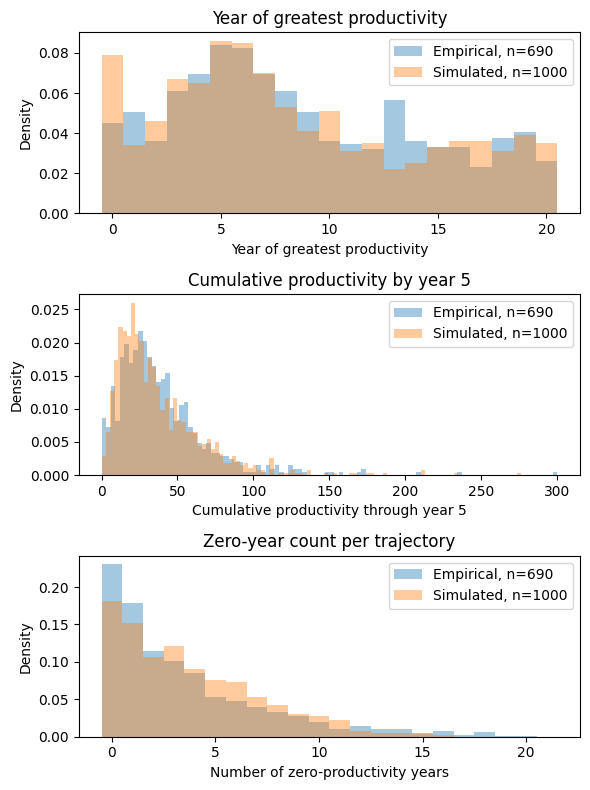

In [24]:
# Cell 15: dx, norm'd

emp_panel = (working_df[working_df["CareerAge"].between(0, Y)].pivot_table(index="dblp_id", columns="CareerAge", values="pubs_adj"))

emp_panel_full = emp_panel.dropna()

emp_year_max = emp_panel_full.idxmax(axis=1)
emp_cum_y5 = emp_panel_full.loc[:, 0:5].sum(axis=1)
emp_zero_count = (emp_panel_full == 0).sum(axis=1)

sim_year_max = np.argmax(trajs_combined, axis=0)
sim_cum_y5 = trajs_combined[0:6, :].sum(axis=0)
sim_zero_count = (trajs_combined == 0).sum(axis=0)

ks_year_max = stats.ks_2samp(emp_year_max, sim_year_max)
ks_cum_y5 = stats.ks_2samp(emp_cum_y5, sim_cum_y5)
ks_zero_count = stats.ks_2samp(emp_zero_count, sim_zero_count)

fig, axes = plt.subplots(3, 1, figsize=(6, 8))

axes[0].hist(emp_year_max,bins=np.arange(-0.5, Y + 1.5, 1),alpha=0.4,density=True,label=f"Empirical, n={len(emp_year_max)}")

axes[0].hist(sim_year_max,bins=np.arange(-0.5, Y + 1.5, 1),alpha=0.4,density=True, label=f"Simulated, n={len(sim_year_max)}")

axes[0].set_xlabel("Year of greatest productivity")
axes[0].set_ylabel("Density")
axes[0].set_title("Year of greatest productivity")
axes[0].legend()

axes[1].hist(emp_cum_y5,bins=100,alpha=0.4,density=True,label=f"Empirical, n={len(emp_cum_y5)}")

axes[1].hist(sim_cum_y5,bins=100,alpha=0.4,density=True,label=f"Simulated, n={len(sim_cum_y5)}")

axes[1].set_xlabel("Cumulative productivity through year 5")
axes[1].set_ylabel("Density")
axes[1].set_title("Cumulative productivity by year 5")
axes[1].legend()

axes[2].hist(emp_zero_count,bins=np.arange(-0.5, Y + 2.5, 1),alpha=0.4,density=True, label=f"Empirical, n={len(emp_zero_count)}")

axes[2].hist(sim_zero_count,bins=np.arange(-0.5, Y + 2.5, 1),alpha=0.4,density=True,label=f"Simulated, n={len(sim_zero_count)}")

axes[2].set_xlabel("Number of zero-productivity years")
axes[2].set_ylabel("Density")
axes[2].set_title("Zero-year count per trajectory")
axes[2].legend()

plt.tight_layout()
plt.savefig(FIGURES / f"{MODEL_TAG}_distribs.png", dpi=300, bbox_inches="tight")
plt.show()

# print("Full empirical trajectories:", len(emp_panel_full))
# print("Simulated trajectories:", trajs_combined.shape[1])
# print("KS year of greatest productivity:", ks_year_max)
# print("KS cumulative productivity by year 5:", ks_cum_y5)
# print("KS zero-year count:", ks_zero_count)


In [25]:
# Cell 18: numerical summary

summary = {
    "empirical_mean_y0": emp_mean.loc[0],
    "empirical_mean_y5": emp_mean.loc[5],
    "empirical_mean_y10": emp_mean.loc[10],
    "empirical_mean_y20": emp_mean.loc[20],
    "simulated_mean_y0": sim_mean[0],
    "simulated_mean_y5": sim_mean[5],
    "simulated_mean_y10": sim_mean[10],
    "simulated_mean_y20": sim_mean[20],
    "empirical_median_y0": emp_median.loc[0],
    "empirical_median_y5": emp_median.loc[5],
    "empirical_median_y10": emp_median.loc[10],
    "empirical_median_y20": emp_median.loc[20],
    "simulated_median_y0": sim_median[0],
    "simulated_median_y5": sim_median[5],
    "simulated_median_y10": sim_median[10],
    "simulated_median_y20": sim_median[20],
    "empirical_frac_zero_y0": emp_frac_zero.loc[0],
    "empirical_frac_zero_y5": emp_frac_zero.loc[5],
    "empirical_frac_zero_y10": emp_frac_zero.loc[10],
    "empirical_frac_zero_y20": emp_frac_zero.loc[20],
    "simulated_frac_zero_y0": sim_frac_zero[0],
    "simulated_frac_zero_y5": sim_frac_zero[5],
    "simulated_frac_zero_y10": sim_frac_zero[10],
    "simulated_frac_zero_y20": sim_frac_zero[20],
    "scholar_effect_tau_mom": tau_scholar,
    "scholar_effect_sd_empirical_shrunk": scholar_effect_sd_empirical,
    "scholar_effect_draw_mode": SCHOLAR_EFFECT_DRAW_MODE,
    "init_active_scholar_coef_per_tau": fitted_init_active_scholar_coef,
    "dropout_gamma_log1p_q": fitted_gamma,
    "dropout_scholar_coef_per_tau": fitted_dropout_scholar_coef,
    "dropout_nll": opt.fun,
    "restart_scholar_coef_per_tau": fitted_restart_scholar_coef,
    "restart_nll": restart_opt.fun,
    "positive_ar1_scholar_coef_per_tau": fitted_positive_ar1_scholar_coef,
    "p_init_active_raw": p_init_active,
    "alpha_q0_pos": alpha_q0_pos,
    "lambda_q0_pos": lambda_q0_pos,
    "alpha_restart": alpha_restart,
    "lambda_restart": lambda_restart,
    "restart_n": len(restart_q_empirical),
    "simulated_y20_q95": np.quantile(trajs_combined[20], 0.95),
    "simulated_y20_q99": np.quantile(trajs_combined[20], 0.99),
    "simulated_y20_max": np.max(trajs_combined[20]),
    "ks_year_max_stat": ks_year_max.statistic,
    "ks_year_max_p": ks_year_max.pvalue,
    "ks_cum_y5_stat": ks_cum_y5.statistic,
    "ks_cum_y5_p": ks_cum_y5.pvalue,
    "ks_zero_count_stat": ks_zero_count.statistic,
    "ks_zero_count_p": ks_zero_count.pvalue}

summary_df = pd.DataFrame([summary])

# print("Yearwise unconditioned transition summary, retained for comparison")
# display(year_transition_summary.round(3))

# print("Scholar effect summary")
# display(scholar_effect_summary.round(4))

# print("Parametric productivity + scholar-effect dropout model summary")
# display(dropout_param_summary.round(4))

# print("Parametric scholar-effect restart model summary")
# display(restart_param_summary.round(4))

# print("Yearwise positive-only AR(1) params")
# display(year_ar1_params)

# print("Exponential initial/restart params")
# display(pd.DataFrame([{
#     "alpha_restart": alpha_restart,
#     "lambda_restart": lambda_restart,
#     "restart_n": len(restart_q_empirical),
#     "alpha_q0_pos": alpha_q0_pos,
#     "lambda_q0_pos": lambda_q0_pos,
#     "p_init_active_raw": p_init_active,
#     "tau_scholar": tau_scholar,
#     "init_active_scholar_coef_per_tau": fitted_init_active_scholar_coef,
#     "dropout_gamma_log1p_q": fitted_gamma,
#     "dropout_scholar_coef_per_tau": fitted_dropout_scholar_coef,
#     "restart_scholar_coef_per_tau": fitted_restart_scholar_coef,
#     "positive_ar1_scholar_coef_per_tau": fitted_positive_ar1_scholar_coef,}]))

# print("Summary")
# display(summary_df)


In [26]:
# Cell 19: save outputs

year_transition_summary.to_csv(RESULTS / f"{MODEL_TAG}_yearTransitionSummary.csv", index=False)
stage_transition_summary.to_csv(RESULTS / f"{MODEL_TAG}_stageTransitionSummary.csv", index=False)
scholar_effect_summary.to_csv(RESULTS / f"{MODEL_TAG}_scholarEffectSummary.csv", index=False)
scholar_effect_df.to_csv(RESULTS / f"{MODEL_TAG}_scholarEffects_empiricalEstimated.csv", index=False)
dropout_param_summary.to_csv(RESULTS / f"{MODEL_TAG}_paramDropoutSummary.csv", index=False)
restart_param_summary.to_csv(RESULTS / f"{MODEL_TAG}_paramRestartSummary.csv", index=False)
year_ar1_params.to_csv(RESULTS / f"{MODEL_TAG}_posYearLog.csv", index=False)
global_ar1_params.to_csv(RESULTS / f"{MODEL_TAG}_pos_globalLog.csv", index=False)
emp_year_stats.to_csv(RESULTS / f"{MODEL_TAG}_empYearStats.csv", index=False)
sim_year_stats.to_csv(RESULTS / f"{MODEL_TAG}_simYearStats.csv", index=False)
emp_delta_stats.to_csv(RESULTS / f"{MODEL_TAG}_empLogDeltaStats.csv", index=False)
sim_delta_stats.to_csv(RESULTS / f"{MODEL_TAG}_simLogDeltaStats.csv", index=False)
summary_df.to_csv(RESULTS / f"{MODEL_TAG}_Summary.csv", index=False)

def matrix_dict_to_frame(matrix_dict, level_name):
    rows = []
    for key, mat in matrix_dict.items():
        rows.append({
            level_name: key,
            "P_nothing_to_nothing": mat.loc[0, 0],
            "P_nothing_to_something": mat.loc[0, 1],
            "P_something_to_nothing": mat.loc[1, 0],
            "P_something_to_something": mat.loc[1, 1]})
    return pd.DataFrame(rows)

matrix_dict_to_frame(year_P, "year").to_csv(RESULTS / f"{MODEL_TAG}_yearPMatrices_comparison.csv", index=False)
matrix_dict_to_frame(stage_P, "stage").to_csv(RESULTS / f"{MODEL_TAG}_stagePMatrices_comparison.csv", index=False)

pd.DataFrame({
    "year": np.arange(Y),
    "restart_prob_if_zero_u_mid": restart_prob_by_year,
    "dropout_intercept": fitted_intercepts,
    "dropout_gamma_log1p_q": fitted_gamma,
    "dropout_scholar_coef_per_tau": fitted_dropout_scholar_coef,
    "pred_drop_q50_u_low": [predict_dropout_prob(q_ref[0.50], year, scholar_effect=-tau_scholar) for year in range(Y)],
    "pred_drop_q50_u_mid": [predict_dropout_prob(q_ref[0.50], year, scholar_effect=0.0) for year in range(Y)],
    "pred_drop_q50_u_high": [predict_dropout_prob(q_ref[0.50], year, scholar_effect=tau_scholar) for year in range(Y)],
    "restart_intercept": fitted_restart_intercepts,
    "restart_scholar_coef_per_tau": fitted_restart_scholar_coef,
    "pred_restart_u_low": [predict_restart_prob(year, scholar_effect=-tau_scholar) for year in range(Y)],
    "pred_restart_u_mid": [predict_restart_prob(year, scholar_effect=0.0) for year in range(Y)],
    "pred_restart_u_high": [predict_restart_prob(year, scholar_effect=tau_scholar) for year in range(Y)],
    "positive_ar1_scholar_coef_per_tau": fitted_positive_ar1_scholar_coef,
}).to_csv(RESULTS / f"{MODEL_TAG}_paramHurdleParams.csv", index=False)

with open(RESULTS / f"{MODEL_TAG}_report.txt", "w") as f:
    f.write("parametric productivity- and scholar-effect-conditioned hurdle yearwise AR(1) report\n\n")
    f.write("Model\n\n")
    f.write("u_i is a latent scholar effect estimated from centered positive log productivity with empirical-Bayes shrinkage.\n")
    f.write("u_i is drawn from the estimated population distribution for simulated scholars.\n")
    f.write("B_0 ~ Bernoulli(logistic(eta_0 + phi_0 u_i/tau)).\n")
    f.write("Q_0 ~ Exponential(lambda_0) if B_0=1; otherwise Q_0=0.\n")
    f.write("If B_t=0, Pr(B_{t+1}=1 | u_i) = logistic(c_t + phi_R u_i/tau).\n")
    f.write("If B_t=1, Pr(B_{t+1}=0 | Q_t, u_i) = logistic(a_t - gamma log(1 + Q_t) + phi_D u_i/tau), gamma >= 0.\n")
    f.write("Q_{t+1} = 0 if B_{t+1}=0.\n")
    f.write("Q_{t+1} ~ Exponential(lambda_R) if B_t=0 and B_{t+1}=1.\n")
    f.write("log(Q_{t+1}) = intercept_t + beta_t log(Q_t) + phi_Z u_i/tau + error_t if B_t=1 and B_{t+1}=1.\n")
    f.write("error_t ~ Normal(0, sigma_t^2).\n\n")
    f.write(f"EPS = {EPS}\n")
    f.write(f"N = {N}\n")
    f.write(f"Y = {Y}\n")
    f.write(f"SCHOLAR_EFFECT_DRAW_MODE = {SCHOLAR_EFFECT_DRAW_MODE}\n")
    f.write(f"tau_scholar = {tau_scholar}\n")
    f.write(f"scholar_effect_sd_empirical = {scholar_effect_sd_empirical}\n")
    f.write(f"p_init_active_raw = {p_init_active}\n")
    f.write(f"fitted_init_active_intercept = {fitted_init_active_intercept}\n")
    f.write(f"fitted_init_active_scholar_coef = {fitted_init_active_scholar_coef}\n")
    f.write(f"alpha_q0_pos = {alpha_q0_pos}\n")
    f.write(f"lambda_q0_pos = {lambda_q0_pos}\n")
    f.write(f"alpha_restart = {alpha_restart}\n")
    f.write(f"lambda_restart = {lambda_restart}\n")
    f.write(f"dropout_gamma_log1p_q = {fitted_gamma}\n")
    f.write(f"dropout_scholar_coef_per_tau = {fitted_dropout_scholar_coef}\n")
    f.write(f"dropout_nll = {opt.fun}\n")
    f.write(f"restart_scholar_coef_per_tau = {fitted_restart_scholar_coef}\n")
    f.write(f"restart_nll = {restart_opt.fun}\n")
    f.write(f"positive_ar1_scholar_coef_per_tau = {fitted_positive_ar1_scholar_coef}\n\n")
    f.write("Scholar effect summary\n\n")
    f.write(scholar_effect_summary.to_string(index=False))
    f.write("\n\nParametric productivity + scholar-effect dropout summary\n\n")
    f.write(dropout_param_summary.to_string(index=False))
    f.write("\n\nParametric scholar-effect restart summary\n\n")
    f.write(restart_param_summary.to_string(index=False))
    f.write("\n\nYearwise binary transition summary, retained for comparison\n\n")
    f.write(year_transition_summary.to_string(index=False))
    f.write("\n\nYearwise positive-only AR(1) parameters\n\n")
    f.write(year_ar1_params.to_string(index=False))
    f.write("\n\nGlobal positive-only AR(1) parameters\n\n")
    f.write(global_ar1_params.to_string(index=False))
    f.write("\n\nsummary\n-------\n")
    f.write(summary_df.to_string(index=False))


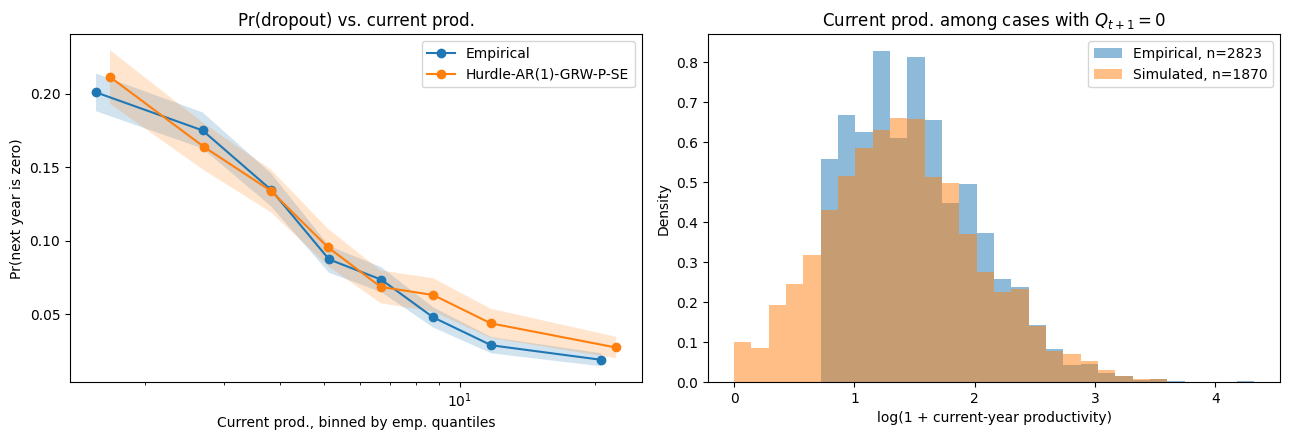

Empirical dropout by current productivity bin:


,prod_bin,n,dropout_rate,mean_q_t,median_q_t,source,bin_mid,se,lower,upper
0,"(1.0890000000000002, 2.181]",3760,0.200798,1.558408,1.502068,Empirical,1.558408,0.006533,0.187993,0.213603
1,"(2.181, 3.229]",3687,0.174939,2.687266,2.644809,Empirical,2.687266,0.006257,0.162676,0.187202
2,"(3.229, 4.419]",3575,0.134545,3.815607,3.811037,Empirical,3.815607,0.005707,0.123359,0.145731
3,"(4.419, 5.829]",3700,0.087297,5.131218,5.084822,Empirical,5.131218,0.004640,0.078202,0.096393
4,"(5.829, 7.622]",3631,0.073533,6.704440,6.691238,Empirical,6.704440,0.004332,0.065044,0.082023
5,"(7.622, 10.037]",3711,0.047966,8.732543,8.706188,Empirical,8.732543,0.003508,0.041090,0.054841
6,"(10.037, 14.001]",3592,0.028953,11.763405,11.657458,Empirical,11.763405,0.002798,0.023470,0.034437
7,"(14.001, 80.687]",3666,0.019094,20.622869,18.392702,Empirical,20.622869,0.002260,0.014664,0.023525


Simulated dropout by current productivity bin:


,prod_bin,n,dropout_rate,mean_q_t,median_q_t,source,bin_mid,se,lower,upper
0,"(1.0890000000000002, 2.181]",1922,0.211238,1.674016,1.694086,Simulated,1.674016,0.009311,0.192989,0.229487
1,"(2.181, 3.229]",2096,0.163645,2.709556,2.715114,Simulated,2.709556,0.008081,0.147807,0.179483
2,"(3.229, 4.419]",2116,0.133743,3.814833,3.820104,Simulated,3.814833,0.007399,0.119240,0.148246
3,"(4.419, 5.829]",2083,0.095535,5.099855,5.101794,Simulated,5.099855,0.006441,0.082912,0.108159
4,"(5.829, 7.622]",1981,0.068652,6.680497,6.667851,Simulated,6.680497,0.005681,0.057517,0.079787
5,"(7.622, 10.037]",1759,0.063104,8.742016,8.680381,Simulated,8.742016,0.005798,0.051741,0.074467
6,"(10.037, 14.001]",1641,0.043876,11.725504,11.557085,Simulated,11.725504,0.005056,0.033966,0.053786
7,"(14.001, 80.687]",1930,0.027461,22.236191,19.150476,Simulated,22.236191,0.003720,0.020170,0.034752


In [27]:
# conditioned dropout 

emp_dx = working_df_fit.loc[working_df_fit["pubs_adj"].notna() & working_df_fit["pubs_adj_next"].notna(),["CareerAge", "pubs_adj", "pubs_adj_next"]].copy()

emp_dx = emp_dx.loc[emp_dx["pubs_adj"] > 0].copy()
emp_dx["drops_to_zero"] = (emp_dx["pubs_adj_next"] == 0).astype(int)


sim_dx = pd.DataFrame({"CareerAge": np.repeat(np.arange(Y), trajs_combined.shape[1]),"pubs_adj": trajs_combined[:-1, :].ravel(),"pubs_adj_next": trajs_combined[1:, :].ravel()})

sim_dx = sim_dx.loc[sim_dx["pubs_adj"] > 0].copy()
sim_dx["drops_to_zero"] = (sim_dx["pubs_adj_next"] == 0).astype(int)

n_bins = 8

bin_edges = np.quantile(emp_dx["pubs_adj"], np.linspace(0, 1, n_bins + 1))

bin_edges = np.unique(bin_edges)

if len(bin_edges) < 3:
    raise ValueError("Not enough unique emp bin edges")

emp_dx["prod_bin"] = pd.cut(emp_dx["pubs_adj"],bins=bin_edges,include_lowest=True,duplicates="drop")

sim_dx["prod_bin"] = pd.cut(sim_dx["pubs_adj"],bins=bin_edges,include_lowest=True,duplicates="drop")

def summarize_dropout_by_bin(df, label):
    out = (df.groupby("prod_bin", observed=False).agg(n=("drops_to_zero", "size"),dropout_rate=("drops_to_zero", "mean"),mean_q_t=("pubs_adj", "mean"),median_q_t=("pubs_adj", "median")).reset_index())

    out["source"] = label
    out["bin_mid"] = out["mean_q_t"]

    out["se"] = np.sqrt(out["dropout_rate"] * (1 - out["dropout_rate"]) / out["n"])
    out["lower"] = np.clip(out["dropout_rate"] - 1.96 * out["se"], 0, 1)
    out["upper"] = np.clip(out["dropout_rate"] + 1.96 * out["se"], 0, 1)

    return out

emp_bin_summary = summarize_dropout_by_bin(emp_dx, "Empirical")
sim_bin_summary = summarize_dropout_by_bin(sim_dx, "Simulated")

dropout_bin_summary = pd.concat([emp_bin_summary, sim_bin_summary], ignore_index=True)


fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(emp_bin_summary["bin_mid"],emp_bin_summary["dropout_rate"],marker="o",label="Empirical")

axes[0].fill_between(emp_bin_summary["bin_mid"],emp_bin_summary["lower"],emp_bin_summary["upper"],alpha=0.20)

axes[0].plot(sim_bin_summary["bin_mid"],sim_bin_summary["dropout_rate"],marker="o",label=MODEL_NAME)

axes[0].fill_between(sim_bin_summary["bin_mid"],sim_bin_summary["lower"],sim_bin_summary["upper"],alpha=0.20)

axes[0].set_xlabel("Current prod., binned by emp. quantiles")
axes[0].set_ylabel("Pr(next year is zero)")
axes[0].set_title("Pr(dropout) vs. current prod.")
axes[0].legend()

axes[0].set_xscale("log")

emp_prezero = emp_dx.loc[emp_dx["drops_to_zero"] == 1, "pubs_adj"]
sim_prezero = sim_dx.loc[sim_dx["drops_to_zero"] == 1, "pubs_adj"]

hist_bins = np.histogram_bin_edges(np.log1p(pd.concat([emp_prezero, sim_prezero])),bins=30)

axes[1].hist(np.log1p(emp_prezero),bins=hist_bins,density=True,alpha=0.5,label=f"Empirical, n={len(emp_prezero)}")

axes[1].hist(np.log1p(sim_prezero),bins=hist_bins,density=True,alpha=0.5,label=f"Simulated, n={len(sim_prezero)}")

axes[1].set_xlabel("log(1 + current-year productivity)")
axes[1].set_ylabel("Density")
axes[1].set_title(r"Current prod. among cases with $Q_{t+1}=0$")
axes[1].legend()

plt.tight_layout()
plt.show()

fig.savefig(FIGURES / f"{MODEL_TAG}_paramCondProdDropout.png",dpi=300,bbox_inches="tight")

dropout_bin_summary.to_csv(RESULTS / f"{MODEL_TAG}_paramCondProdDropoutSummary.csv", index=False)

print("Empirical dropout by current productivity bin:")
display(emp_bin_summary)

print("Simulated dropout by current productivity bin:")
display(sim_bin_summary)


In [28]:
# save trajectory array

OUT = PROJ_ROOT / "data" / 'trajectory_correlation_data'
OUT.mkdir(parents=True, exist_ok=True)

TRJ = trajs_combined

TRJ = np.asarray(TRJ)
if TRJ.shape[0] != 21 and TRJ.shape[1] == 21:
    TRJ = TRJ.T

assert TRJ.shape[0] == 21, f"expected 21 years, got {TRJ.shape}"

save_path = OUT / f"{MODEL_TAG}_trajs.npy"
np.save(save_path, TRJ)

u_save_path = OUT / f"{MODEL_TAG}_scholar_effects.npy"
np.save(u_save_path, np.asarray(scholar_effects_simulated))


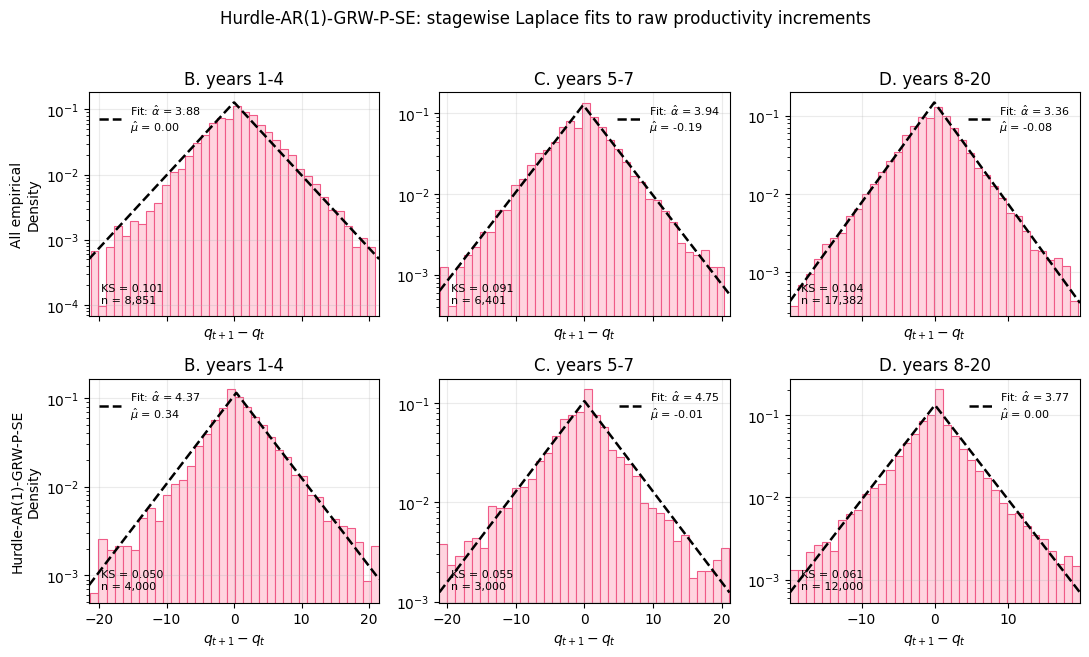

,model,source,stage,n,mu_hat,alpha_hat,ks_stat,mean,sd,q01,q50,q99
0,All empirical,empirical,B. years 1-4,8851,0.000000,3.879470,0.101040,0.756686,5.414004,-13.371327,0.000000,15.428888
1,All empirical,empirical,C. years 5-7,6401,-0.190708,3.937165,0.090950,-0.429310,5.622345,-15.275857,-0.190708,15.502144
2,All empirical,empirical,D. years 8-20,17382,-0.079308,3.363053,0.104041,-0.220967,4.886889,-13.966737,-0.079308,13.732907
3,Hurdle-AR(1)-GRW-P-SE,simulated,B. years 1-4,4000,0.336280,4.368123,0.049702,0.804935,6.958519,-18.283523,0.336280,21.473471
4,Hurdle-AR(1)-GRW-P-SE,simulated,C. years 5-7,3000,-0.013979,4.748566,0.054951,-0.508723,7.583037,-21.094345,-0.013979,20.779052
5,Hurdle-AR(1)-GRW-P-SE,simulated,D. years 8-20,12000,0.000000,3.765846,0.060714,-0.091409,6.719143,-18.444763,0.000000,18.748161


In [29]:
# cell 17: laplace

stage_years = {
    "B. years 1-4": np.arange(1, 5),
    "C. years 5-7": np.arange(5, 8),
    "D. years 8-20": np.arange(8, Y)}

def laplace_fit(x):
    x = pd.Series(x).replace([np.inf, -np.inf], np.nan).dropna().to_numpy()
    mu = np.median(x)
    alpha = np.mean(np.abs(x - mu))
    ks = stats.kstest(x, "laplace", args=(mu, alpha)).statistic
    return mu, alpha, ks, len(x)

def laplace_pdf(x, mu, alpha):
    return (1 / (2 * alpha)) * np.exp(-np.abs(x - mu) / alpha)

def sim_stage_dx(trj, yrs):
    dx = trj[1:, :] - trj[:-1, :]
    return dx[yrs, :].ravel()

def emp_stage_dx(working_df, yrs):
    emp_dx = working_df.sort_values(["dblp_id", "CareerAge"]).copy()
    emp_dx["pubs_adj_next"] = emp_dx.groupby("dblp_id")["pubs_adj"].shift(-1)
    emp_dx["CareerAge_next"] = emp_dx.groupby("dblp_id")["CareerAge"].shift(-1)
    emp_dx["raw_delta"] = emp_dx["pubs_adj_next"] - emp_dx["pubs_adj"]

    keep = emp_dx["CareerAge_next"].eq(emp_dx["CareerAge"] + 1)
    keep &= emp_dx["CareerAge"].isin(yrs)

    return emp_dx.loc[keep, "raw_delta"].dropna().to_numpy()

plot_sources = [(MODEL_NAME, "simulated", TRJ)]

plot_sources = [("All empirical", "empirical", None)] + plot_sources

laplace_rows = []

xlims = {}
for stage, yrs in stage_years.items():
    pooled = []
    pooled.append(emp_stage_dx(working_df, yrs))

    pooled.append(sim_stage_dx(TRJ, yrs))

    pooled = np.concatenate([x for x in pooled if len(x) > 0])
    lo, hi = np.quantile(pooled, [0.005, 0.995])
    lim = max(abs(lo), abs(hi), 1)
    xlims[stage] = (-lim, lim)

fig, axes = plt.subplots(len(plot_sources), 3, figsize=(11, 3.2 * len(plot_sources)), sharex="col", sharey=False)

if len(plot_sources) == 1:
    axes = np.array([axes])

for r, (source_name, source_type, trj) in enumerate(plot_sources):
    for c, (stage, yrs) in enumerate(stage_years.items()):
        ax = axes[r, c]

        if source_type == "empirical":
            x = emp_stage_dx(working_df, yrs)
        else:
            x = sim_stage_dx(trj, yrs)

        mu, alpha, ks, n = laplace_fit(x)
        lo, hi = xlims[stage]
        x_plot = x[(x >= lo) & (x <= hi)]

        ax.hist(x_plot,bins=36,density=True,color="#ffd4df",edgecolor="#f05a87",linewidth=0.8)

        xx = np.linspace(lo, hi, 600)
        ax.plot(xx,laplace_pdf(xx, mu, alpha),linestyle="--",color="black",linewidth=1.8,label=rf"Fit: $\hat\alpha$ = {alpha:.2f}" + "\n" + rf"$\hat\mu$ = {mu:.2f}")

        ax.set_yscale("log")
        ax.set_xlim(lo, hi)
        ax.grid(alpha=0.25)
        ax.legend(frameon=False, fontsize=8)
        ax.set_title(stage)
        ax.set_xlabel(r"$q_{t+1} - q_t$")

        if c == 0:
            ax.set_ylabel(f"{source_name}\nDensity")

        ax.text(0.04,0.06,f"KS = {ks:.3f}\nn = {n:,}",transform=ax.transAxes,fontsize=8)

        laplace_rows.append({
            "model": source_name,
            "source": source_type,
            "stage": stage,
            "n": n,
            "mu_hat": mu,
            "alpha_hat": alpha,
            "ks_stat": ks,
            "mean": np.mean(x),
            "sd": np.std(x, ddof=0),
            "q01": np.quantile(x, 0.01),
            "q50": np.quantile(x, 0.50),
            "q99": np.quantile(x, 0.99)})

fig.suptitle(f"{MODEL_NAME}: stagewise Laplace fits to raw productivity increments", y=1.02)
fig.tight_layout()

plt.savefig(FIGURES / f"{MODEL_TAG}_stageRawIncrementLaplace.png", dpi=300, bbox_inches="tight")
plt.show()

laplace_stage_summary = pd.DataFrame(laplace_rows)
laplace_stage_summary.to_csv(RESULTS / f"{MODEL_TAG}_stageRawIncrementLaplace.csv", index=False)
laplace_stage_summary

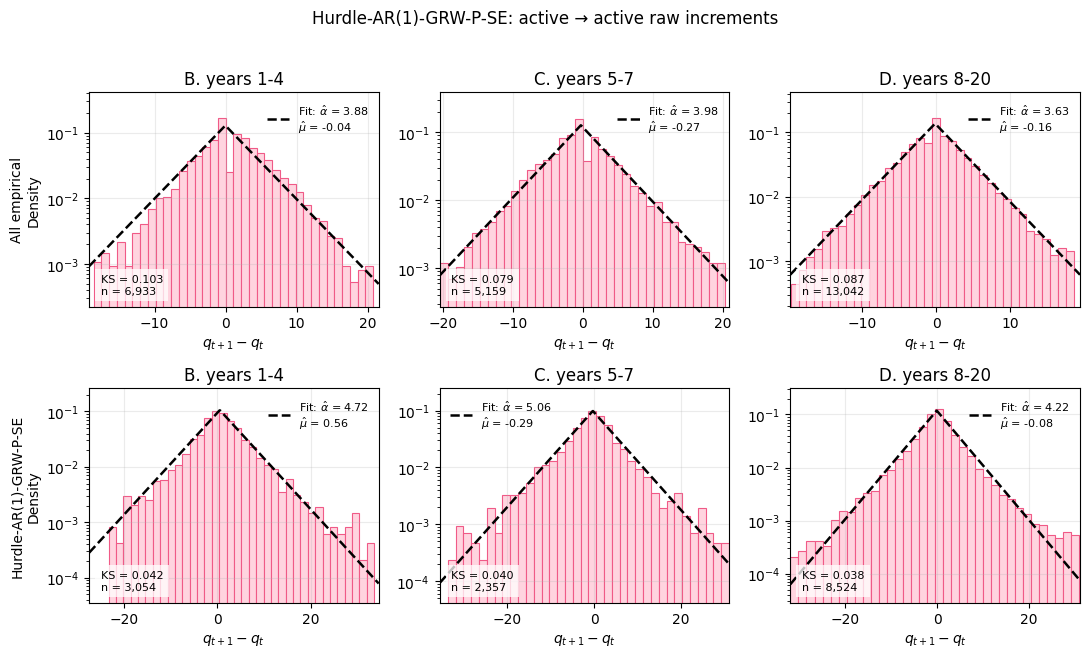

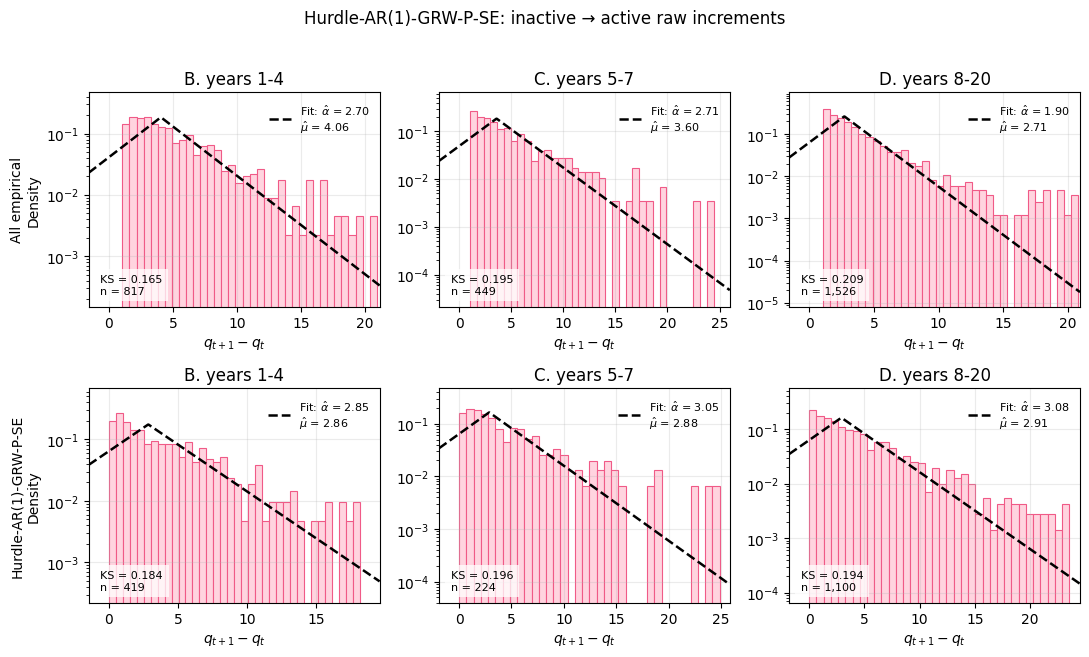

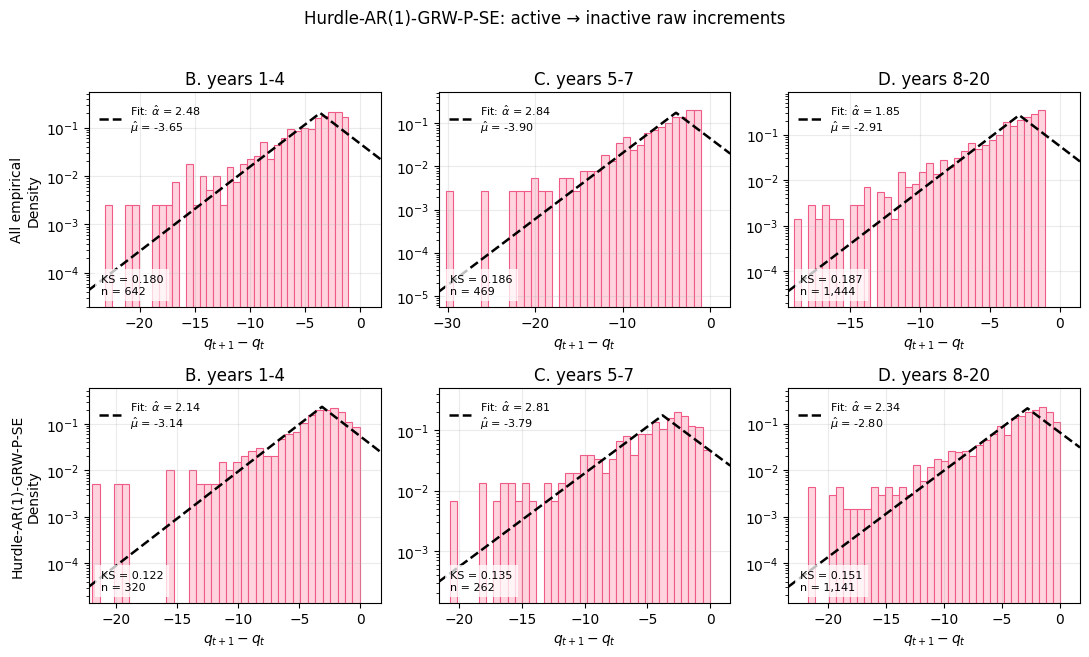

,source,stage,n,mu_hat,alpha_hat,ks_stat,mean,sd,q01,q50,q99,transition,transition_label,emp_q01,emp_q99,frac_outside_emp_1_99
1,Hurdle-AR(1)-GRW-P-SE,B. years 1-4,3054,0.555994,4.723022,0.042270,0.915720,7.481174,-18.950038,0.555994,24.980790,active_to_active,active → active,-12.944834,14.963747,0.061559
0,empirical,B. years 1-4,6933,-0.041633,3.880758,0.102863,0.801682,5.383436,-12.944834,-0.041633,14.963747,active_to_active,active → active,-12.944834,14.963747,NaN
3,Hurdle-AR(1)-GRW-P-SE,C. years 5-7,2357,-0.288372,5.056425,0.039573,-0.520063,8.054836,-23.726703,-0.288372,22.594711,active_to_active,active → active,-15.039792,15.342719,0.061095
2,empirical,C. years 5-7,5159,-0.274955,3.977838,0.079150,-0.483646,5.607226,-15.039792,-0.274955,15.342719,active_to_active,active → active,-15.039792,15.342719,NaN
5,Hurdle-AR(1)-GRW-P-SE,D. years 8-20,8524,-0.076923,4.217715,0.038425,-0.177208,7.392738,-20.443730,-0.076923,20.050485,active_to_active,active → active,-14.437689,14.204638,0.047161
4,empirical,D. years 8-20,13042,-0.161491,3.626348,0.087203,-0.304683,5.165246,-14.437689,-0.161491,14.204638,active_to_active,active → active,-14.437689,14.204638,NaN
13,Hurdle-AR(1)-GRW-P-SE,B. years 1-4,320,-3.139075,2.137944,0.121813,-4.002750,3.469741,-18.625706,-3.139075,-0.265285,active_to_inactive,active → inactive,-18.394683,-1.231551,0.128125
12,empirical,B. years 1-4,642,-3.651052,2.483994,0.180132,-4.898404,3.845452,-18.394683,-3.651052,-1.231551,active_to_inactive,active → inactive,-18.394683,-1.231551,NaN
15,Hurdle-AR(1)-GRW-P-SE,C. years 5-7,262,-3.789978,2.810395,0.134989,-4.980117,4.008040,-18.199479,-3.789978,-0.095999,active_to_inactive,active → inactive,-21.927045,-1.146671,0.091603
14,empirical,C. years 5-7,469,-3.902057,2.836703,0.185601,-5.185207,4.451195,-21.927045,-3.902057,-1.146671,active_to_inactive,active → inactive,-21.927045,-1.146671,NaN


In [30]:
# Cell 19B: transition-specific raw increment Laplace dx


ACTIVE_TOL = 0

transition_classes = {
    "active_to_active": "active → active",
    "inactive_to_active": "inactive → active",
    "active_to_inactive": "active → inactive",
    "inactive_to_inactive": "inactive → inactive"}

plot_transitions = [
    "active_to_active",
    "inactive_to_active",
    "active_to_inactive"]

def laplace_fit(x):
    x = pd.Series(x).replace([np.inf, -np.inf], np.nan).dropna().to_numpy()

    if len(x) == 0:
        return np.nan, np.nan, np.nan, 0

    mu = np.median(x)
    alpha = np.mean(np.abs(x - mu))

    if alpha <= 0 or not np.isfinite(alpha):
        return mu, alpha, np.nan, len(x)

    ks = stats.kstest(x, "laplace", args=(mu, alpha)).statistic
    return mu, alpha, ks, len(x)

def laplace_pdf(x, mu, alpha):
    return (1 / (2 * alpha)) * np.exp(-np.abs(x - mu) / alpha)

def transition_label(q0, q1):
    active0 = q0 > ACTIVE_TOL
    active1 = q1 > ACTIVE_TOL

    out = np.full(q0.shape, "inactive_to_inactive", dtype=object)
    out[active0 & active1] = "active_to_active"
    out[(~active0) & active1] = "inactive_to_active"
    out[active0 & (~active1)] = "active_to_inactive"

    return out

def sim_transition_dx(trj, yrs, transition):
    q0 = trj[:-1, :]
    q1 = trj[1:, :]
    dx = q1 - q0
    lab = transition_label(q0, q1)

    keep_year = np.isin(np.arange(q0.shape[0]), yrs)[:, None]
    keep = keep_year & (lab == transition)

    return dx[keep]

def emp_transition_frame(working_df):
    emp_dx = working_df.sort_values(["dblp_id", "CareerAge"]).copy()
    emp_dx["pubs_adj_next"] = emp_dx.groupby("dblp_id")["pubs_adj"].shift(-1)
    emp_dx["CareerAge_next"] = emp_dx.groupby("dblp_id")["CareerAge"].shift(-1)
    emp_dx["raw_delta"] = emp_dx["pubs_adj_next"] - emp_dx["pubs_adj"]

    keep = emp_dx["CareerAge_next"].eq(emp_dx["CareerAge"] + 1)
    emp_dx = emp_dx.loc[keep].copy()

    q0 = emp_dx["pubs_adj"].to_numpy()
    q1 = emp_dx["pubs_adj_next"].to_numpy()

    emp_dx["transition"] = transition_label(q0, q1)

    return emp_dx

def emp_transition_dx(emp_dx, yrs, transition):
    keep = emp_dx["CareerAge"].isin(yrs)
    keep &= emp_dx["transition"].eq(transition)

    return emp_dx.loc[keep, "raw_delta"].dropna().to_numpy()

def panel_xlim(x, q=0.995, pad=0.08):
    x = pd.Series(x).replace([np.inf, -np.inf], np.nan).dropna().to_numpy()

    if len(x) == 0:
        return -1, 1

    lo, hi = np.quantile(x, [1 - q, q])
    lo = min(lo, 0)
    hi = max(hi, 0)

    span = max(hi - lo, 1)
    return lo - pad * span, hi + pad * span

def plot_dx_panel(ax, x, title, source_name):
    x = pd.Series(x).replace([np.inf, -np.inf], np.nan).dropna().to_numpy()
    mu, alpha, ks, n = laplace_fit(x)
    lo, hi = panel_xlim(x)

    x_plot = x[(x >= lo) & (x <= hi)]

    if len(x_plot) > 0:
        counts, edges = np.histogram(x_plot, bins=36, density=True)
        widths = np.diff(edges)
        keep = counts > 0

        ax.bar(
            edges[:-1][keep],
            counts[keep],
            width=widths[keep],
            align="edge",
            color="#ffd4df",
            edgecolor="#f05a87",
            linewidth=0.8
        )

        y_pos = counts[counts > 0]
    else:
        y_pos = np.array([])

    xx = np.linspace(lo, hi, 600)

    if np.isfinite(alpha) and alpha > 0:
        yy = laplace_pdf(xx, mu, alpha)
        ax.plot(
            xx,
            yy,
            linestyle="--",
            color="black",
            linewidth=1.8,
            label=rf"Fit: $\hat\alpha$ = {alpha:.2f}" + "\n" + rf"$\hat\mu$ = {mu:.2f}"
        )

        y_pos = np.r_[y_pos, yy[np.isfinite(yy) & (yy > 0)]]

    if len(y_pos) > 0:
        ax.set_ylim(max(y_pos.min() * 0.45, 1e-6), y_pos.max() * 2.5)

    ax.set_yscale("log")
    ax.set_xlim(lo, hi)
    ax.grid(alpha=0.25)
    ax.legend(frameon=False, fontsize=8)
    ax.set_title(title)
    ax.set_xlabel(r"$q_{t+1} - q_t$")

    ax.text(
        0.04,
        0.06,
        f"KS = {ks:.3f}\nn = {n:,}",
        transform=ax.transAxes,
        fontsize=8,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.75)
    )

    return {
        "source": source_name,
        "stage": title,
        "n": n,
        "mu_hat": mu,
        "alpha_hat": alpha,
        "ks_stat": ks,
        "mean": np.mean(x) if len(x) else np.nan,
        "sd": np.std(x, ddof=0) if len(x) else np.nan,
        "q01": np.quantile(x, 0.01) if len(x) else np.nan,
        "q50": np.quantile(x, 0.50) if len(x) else np.nan,
        "q99": np.quantile(x, 0.99) if len(x) else np.nan}

emp_dx = emp_transition_frame(working_df)
transition_rows = []

for transition in plot_transitions:
    fig, axes = plt.subplots(2, 3, figsize=(11, 6.4))

    for c, (stage, yrs) in enumerate(stage_years.items()):
        x_emp = emp_transition_dx(emp_dx, yrs, transition)
        x_sim = sim_transition_dx(TRJ, yrs, transition)

        row = plot_dx_panel(axes[0, c], x_emp, stage, "empirical")
        row["transition"] = transition
        row["transition_label"] = transition_classes[transition]
        transition_rows.append(row)

        row = plot_dx_panel(axes[1, c], x_sim, stage, MODEL_NAME)
        row["transition"] = transition
        row["transition_label"] = transition_classes[transition]
        transition_rows.append(row)

        if c == 0:
            axes[0, c].set_ylabel("All empirical\nDensity")
            axes[1, c].set_ylabel(f"{MODEL_NAME}\nDensity")

    fig.suptitle(
        f"{MODEL_NAME}: {transition_classes[transition]} raw increments",
        y=1.02
    )

    fig.tight_layout()
    plt.savefig(
        FIGURES / f"{MODEL_TAG}_{transition}_rawIncrementLaplace.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

for transition in transition_classes:
    for stage, yrs in stage_years.items():
        x_emp = emp_transition_dx(emp_dx, yrs, transition)
        x_sim = sim_transition_dx(TRJ, yrs, transition)

        if transition == "inactive_to_inactive":
            for source_name, x in [("empirical", x_emp), (MODEL_NAME, x_sim)]:
                transition_rows.append({
                    "source": source_name,
                    "stage": stage,
                    "transition": transition,
                    "transition_label": transition_classes[transition],
                    "n": len(x),
                    "mu_hat": 0,
                    "alpha_hat": 0,
                    "ks_stat": np.nan,
                    "mean": 0,
                    "sd": 0,
                    "q01": 0,
                    "q50": 0,
                    "q99": 0
                })

transition_laplace_summary = pd.DataFrame(transition_rows)

emp_bounds = (
    transition_laplace_summary
    .query("source == 'empirical'")
    [["stage", "transition", "q01", "q99"]]
    .rename(columns={"q01": "emp_q01", "q99": "emp_q99"})
)

transition_laplace_summary = transition_laplace_summary.merge(
    emp_bounds,
    on=["stage", "transition"],
    how="left"
)

outside_emp = []

for _, row in transition_laplace_summary.iterrows():
    if row["source"] == "empirical":
        outside_emp.append(np.nan)
        continue

    yrs = stage_years[row["stage"]]
    x = sim_transition_dx(TRJ, yrs, row["transition"])

    if len(x) == 0 or not np.isfinite(row["emp_q01"]) or not np.isfinite(row["emp_q99"]):
        outside_emp.append(np.nan)
    else:
        outside_emp.append(((x < row["emp_q01"]) | (x > row["emp_q99"])).mean())

transition_laplace_summary["frac_outside_emp_1_99"] = outside_emp

transition_laplace_summary.to_csv(
    RESULTS / f"{MODEL_TAG}_transitionRawIncrementLaplace.csv",
    index=False
)

transition_laplace_summary.sort_values(["transition", "stage", "source"])

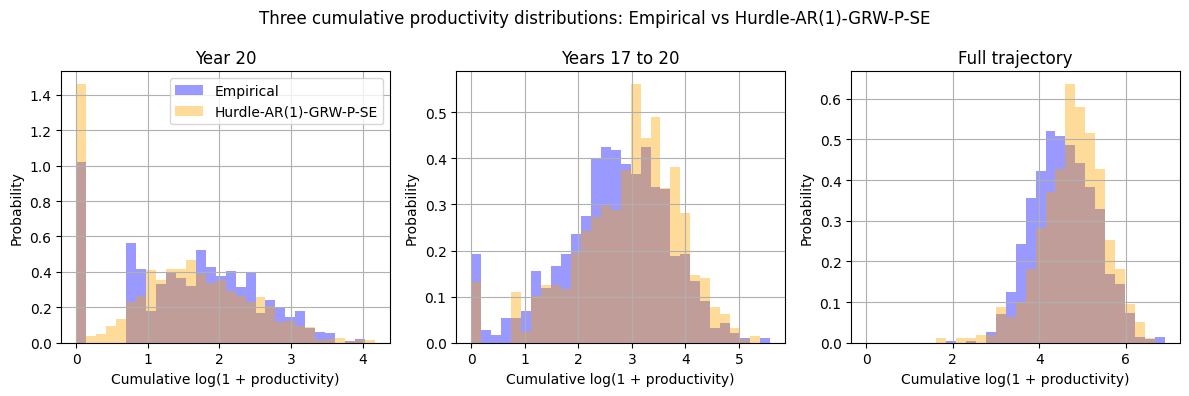

In [31]:
lastyear_sim = trajs_combined[20]
lastyear_emp = emp_panel_full[20]
hist_bins_lastyear = np.histogram_bin_edges((np.log1p(np.concat([[0],lastyear_sim, lastyear_emp]))),bins=30)

lastfour_sim = trajs_combined[-4:,:].sum(axis = 0)
lastfour_emp = emp_panel_full.iloc[:, -4:].sum(axis=1).to_numpy()
hist_bins_lastfour = np.histogram_bin_edges((np.log1p(np.concat([[0],lastfour_sim, lastfour_emp]))),bins=30)

cumsim = trajs_combined.sum(axis = 0)
cumemp = emp_panel_full.sum(axis=1).to_numpy()
hist_bins_cum = np.histogram_bin_edges((np.log1p(np.concat([[0],cumsim, cumemp]))),bins=30)


fig, ax = plt.subplots(1,3, figsize = (12,4))

ax[0].hist(np.log1p(lastyear_emp), bins = hist_bins_lastyear, alpha = 0.4, color = 'blue', label = 'Empirical', density = True)
ax[0].hist(np.log1p(lastyear_sim),bins=hist_bins_lastyear, alpha = 0.4, color = 'orange', label= f'{MODEL_NAME}', density=True)
ax[0].set_xlabel('Cumulative log(1 + productivity)')
ax[0].set_ylabel('Probability')
ax[0].set_title('Year 20')
ax[0].legend()
ax[0].grid(True)

ax[1].hist(np.log1p(lastfour_sim), bins = hist_bins_lastfour, alpha = 0.4, color = 'blue', label= f'{MODEL_NAME}', density = True)
ax[1].hist(np.log1p(lastfour_emp),bins=hist_bins_lastfour, alpha = 0.4, color = 'orange', label= 'Empirical', density=True)
ax[1].set_xlabel('Cumulative log(1 + productivity)')
ax[1].set_ylabel('Probability')
ax[1].set_title('Years 17 to 20')
ax[1].grid(True)

ax[2].hist(np.log1p(cumsim), bins = hist_bins_cum, alpha = 0.4, color = 'blue', label = f'{MODEL_NAME}', density = True)
ax[2].hist(np.log1p(cumemp), bins=hist_bins_cum, alpha = 0.4, color = 'orange', label='Empirical', density=True)
ax[2].set_xlabel('Cumulative log(1 + productivity)')
ax[2].set_ylabel('Probability')
ax[2].set_title('Full trajectory')
ax[2].grid(True)

plt.suptitle(f'Three cumulative productivity distributions: Empirical vs {MODEL_NAME}')
plt.tight_layout()
plt.show()

fig.savefig(FIGURES / f"{MODEL_TAG}_threecumdists.png",dpi=300, bbox_inches="tight")

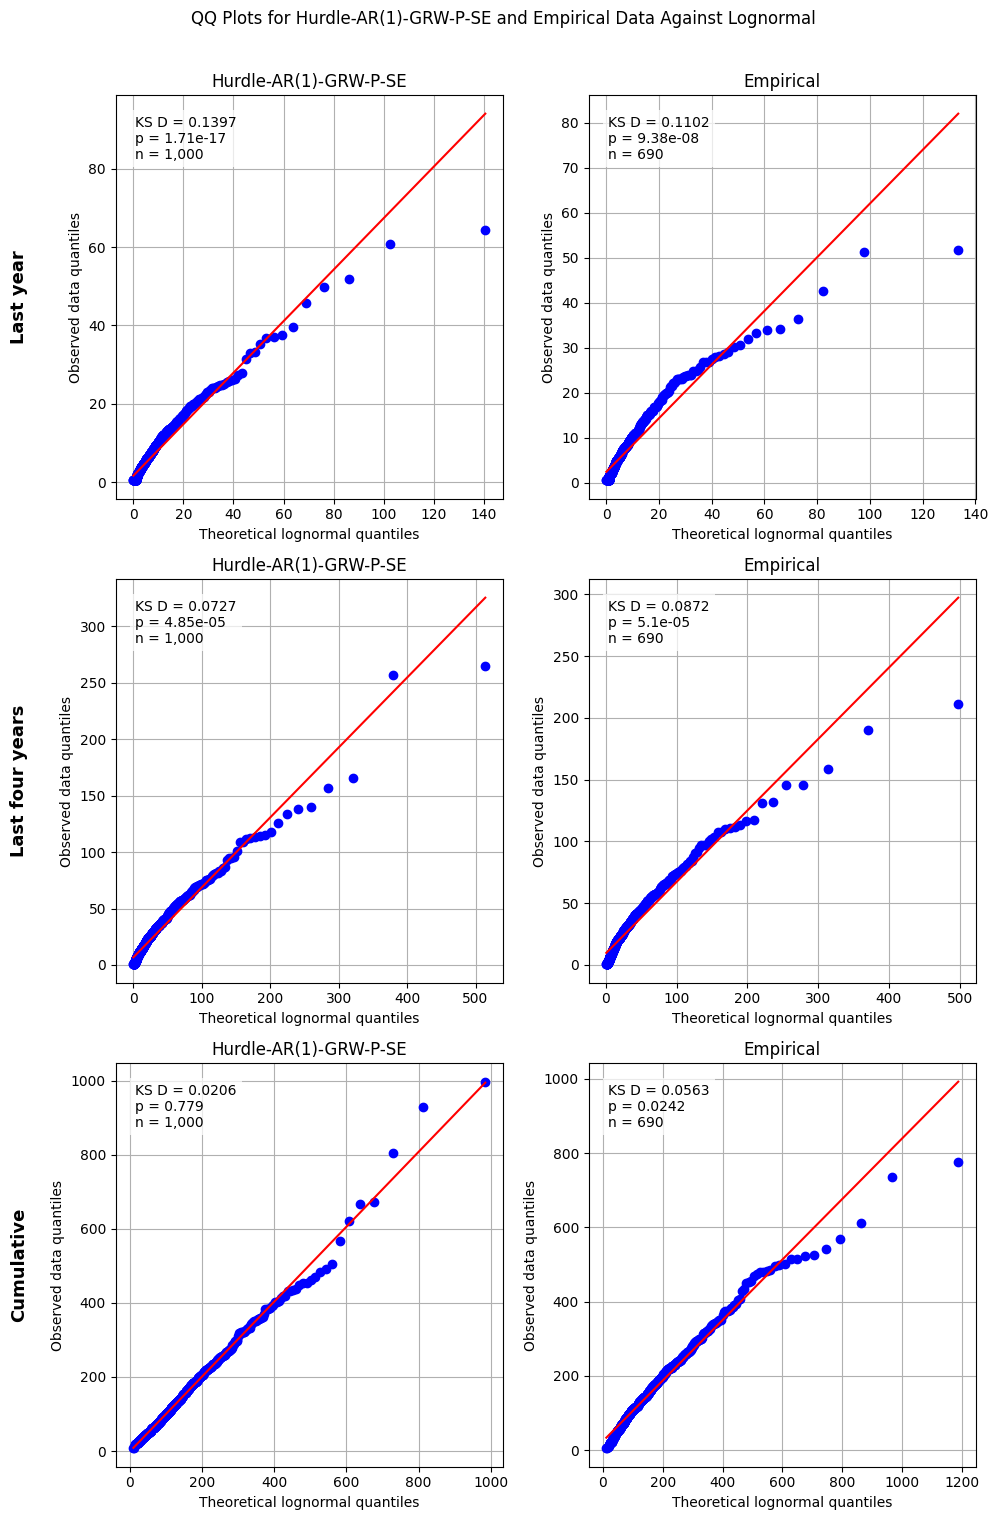

In [32]:

shape_sim_lastyear, loc_sim_lastyear, scale_sim_lastyear = stats.lognorm.fit(np.asarray(lastyear_sim + 0.49), floc=0)
shape_emp_lastyear, loc_emp_lastyear, scale_emp_lastyear = stats.lognorm.fit(np.asarray(lastyear_emp + 0.49), floc = 0)
ks_sim_lastyear = stats.kstest(np.asarray(lastyear_sim) + 0.49, stats.lognorm.cdf, args=(shape_sim_lastyear, loc_sim_lastyear, scale_sim_lastyear))
ks_emp_lastyear = stats.kstest(np.asarray(lastyear_emp) + 0.49, stats.lognorm.cdf, args=(shape_emp_lastyear, loc_emp_lastyear, scale_emp_lastyear))
ks_sim_text_lastyear = f"KS D = {ks_sim_lastyear.statistic:.4f}\np = {ks_sim_lastyear.pvalue:.3g}\nn = {len(lastyear_sim):,}"
ks_emp_text_lastyear = f"KS D = {ks_emp_lastyear.statistic:.4f}\np = {ks_emp_lastyear.pvalue:.3g}\nn = {len(lastyear_emp):,}"



#####


shape_sim_lastfour, loc_sim_lastfour, scale_sim_lastfour = stats.lognorm.fit(np.asarray(lastfour_sim + 0.49), floc=0)
shape_emp_lastfour, loc_emp_lastfour, scale_emp_lastfour = stats.lognorm.fit(np.asarray(lastfour_emp + 0.49), floc = 0)
ks_sim_lastfour = stats.kstest(np.asarray(lastfour_sim) + 0.49, stats.lognorm.cdf, args=(shape_sim_lastfour, loc_sim_lastfour, scale_sim_lastfour))
ks_emp_lastfour = stats.kstest(np.asarray(lastfour_emp) + 0.49, stats.lognorm.cdf, args=(shape_emp_lastfour, loc_emp_lastfour, scale_emp_lastfour))
ks_sim_text_lastfour = f"KS D = {ks_sim_lastfour.statistic:.4f}\np = {ks_sim_lastfour.pvalue:.3g}\nn = {len(lastfour_sim):,}"
ks_emp_text_lastfour = f"KS D = {ks_emp_lastfour.statistic:.4f}\np = {ks_emp_lastfour.pvalue:.3g}\nn = {len(lastfour_emp):,}"


#####


shape_sim_cum, loc_sim_cum, scale_sim_cum = stats.lognorm.fit(np.asarray(cumsim + 0.49), floc=0)
shape_emp_cum, loc_emp_cum, scale_emp_cum = stats.lognorm.fit(np.asarray(cumemp + 0.49), floc = 0)
ks_sim_cum = stats.kstest(np.asarray(cumsim) + 0.49, stats.lognorm.cdf, args=(shape_sim_cum, loc_sim_cum, scale_sim_cum))
ks_emp_cum = stats.kstest(np.asarray(cumemp) + 0.49, stats.lognorm.cdf, args=(shape_emp_cum, loc_emp_cum, scale_emp_cum))
ks_sim_text_cum = f"KS D = {ks_sim_cum.statistic:.4f}\np = {ks_sim_cum.pvalue:.3g}\nn = {len(cumsim):,}"
ks_emp_text_cum = f"KS D = {ks_emp_cum.statistic:.4f}\np = {ks_emp_cum.pvalue:.3g}\nn = {len(cumemp):,}"


#####


EPS = 0.49

fig, ax = plt.subplots(3,2, figsize=(10, 15))

qq_rows = [
    ("Last year", lastyear_sim, lastyear_emp,
     (shape_sim_lastyear, loc_sim_lastyear, scale_sim_lastyear),
     (shape_emp_lastyear, loc_emp_lastyear, scale_emp_lastyear),
     ks_sim_text_lastyear, ks_emp_text_lastyear),

    ("Last four years", lastfour_sim, lastfour_emp,
     (shape_sim_lastfour, loc_sim_lastfour, scale_sim_lastfour),
     (shape_emp_lastfour, loc_emp_lastfour, scale_emp_lastfour),
     ks_sim_text_lastfour, ks_emp_text_lastfour),

    ("Cumulative", cumsim, cumemp,
     (shape_sim_cum, loc_sim_cum, scale_sim_cum),
     (shape_emp_cum, loc_emp_cum, scale_emp_cum),
     ks_sim_text_cum, ks_emp_text_cum),
]

for r, (row_title, sim, emp, sim_params, emp_params, sim_text, emp_text) in enumerate(qq_rows):

    stats.probplot(np.asarray(sim, dtype=float) + EPS, dist=stats.lognorm, sparams=sim_params, plot=ax[r,0])
    stats.probplot(np.asarray(emp, dtype=float) + EPS, dist=stats.lognorm, sparams=emp_params, plot=ax[r,1])

    ax[r,0].set_title(f"{MODEL_NAME}")
    ax[r,1].set_title("Empirical")

    for c, ks_text in enumerate([sim_text, emp_text]):
        ax[r,c].set_xlabel("Theoretical lognormal quantiles")
        ax[r,c].set_ylabel("Observed data quantiles")
        ax[r,c].grid(True)
        ax[r,c].text(0.05, 0.95, ks_text, transform=ax[r,c].transAxes,
                     va="top", ha="left", fontsize=10,
                     bbox=dict(facecolor="white", alpha=0.75, edgecolor="none"))

    ax[r,0].annotate(row_title, xy=(-0.25, 0.5), xycoords="axes fraction",
                     rotation=90, va="center", ha="center",
                     fontsize=13, fontweight="bold")

plt.suptitle(f"QQ Plots for {MODEL_NAME} and Empirical Data Against Lognormal", y=1.01)
plt.tight_layout()

fig.savefig(FIGURES / f"{MODEL_TAG}_qqlognorm_full.png", dpi=300, bbox_inches="tight")
plt.show()

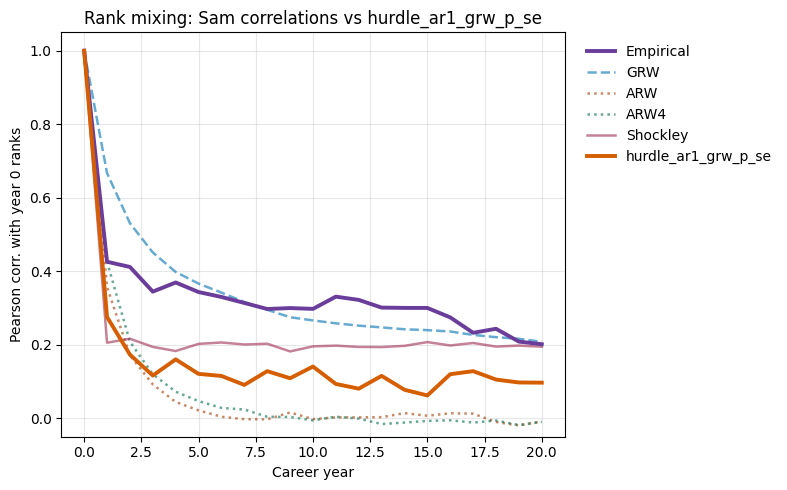

In [33]:
OUT = PROJ_ROOT / "data" / "trajectory_correlation_data"

sams_corr = pd.read_csv(OUT / "sams_correlations.csv")

TRJ = np.asarray(trajs_combined)
rank_0 = pd.Series(TRJ[0]).rank(method="average").to_numpy()

corr_traj = []
for t in range(Y + 1):
    rank_t = pd.Series(TRJ[t]).rank(method="average").to_numpy()
    corr_traj.append(np.corrcoef(rank_0, rank_t)[0, 1])

corr_traj = pd.DataFrame({
    "CareerAge": np.arange(Y + 1),
    MODEL_TAG: corr_traj,})

palette = ["#0072B2", "#A23B00", "#006D4E", "#6A3D9A", "#9E2F50", "#D55E00"]

sams_corr.insert(0, "CareerAge", np.arange(len(sams_corr)))

corr_compare = sams_corr.merge(corr_traj, on="CareerAge", how="left")
corr_compare.to_csv(OUT / f"{MODEL_TAG}_corrCompare.csv", index=False)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(corr_compare["CareerAge"], corr_compare["CS_empirical"], color=palette[3], linewidth=2.8, label="Empirical", zorder=6)
ax.plot(corr_compare["CareerAge"], corr_compare["GRW"], color=palette[0], linestyle="dashed", linewidth=1.8, alpha=0.6, label="GRW")
ax.plot(corr_compare["CareerAge"], corr_compare["ARW"], color=palette[1], linestyle="dotted", linewidth=1.8, alpha=0.6, label="ARW")
ax.plot(corr_compare["CareerAge"], corr_compare["ARW4"], color=palette[2], linestyle="dotted", linewidth=1.8, alpha=0.6, label="ARW4")
ax.plot(corr_compare["CareerAge"], corr_compare["Shockley"], color=palette[4], linewidth=1.8, alpha=0.6, label="Shockley")

ax.plot(corr_compare["CareerAge"], corr_compare[MODEL_TAG], color=palette[5], linewidth=2.8, label=MODEL_TAG, zorder=7)

ax.set_title(f"Rank mixing: Sam correlations vs {MODEL_TAG}")
ax.set_xlabel("Career year")
ax.set_ylabel("Pearson corr. with year 0 ranks")
ax.set_ylim(-0.05, 1.05)
ax.grid(True, alpha=0.3)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)

plt.tight_layout()
plt.savefig(OUT / f"{MODEL_TAG}_corrCompare.png", dpi=300, bbox_inches="tight")
plt.show()


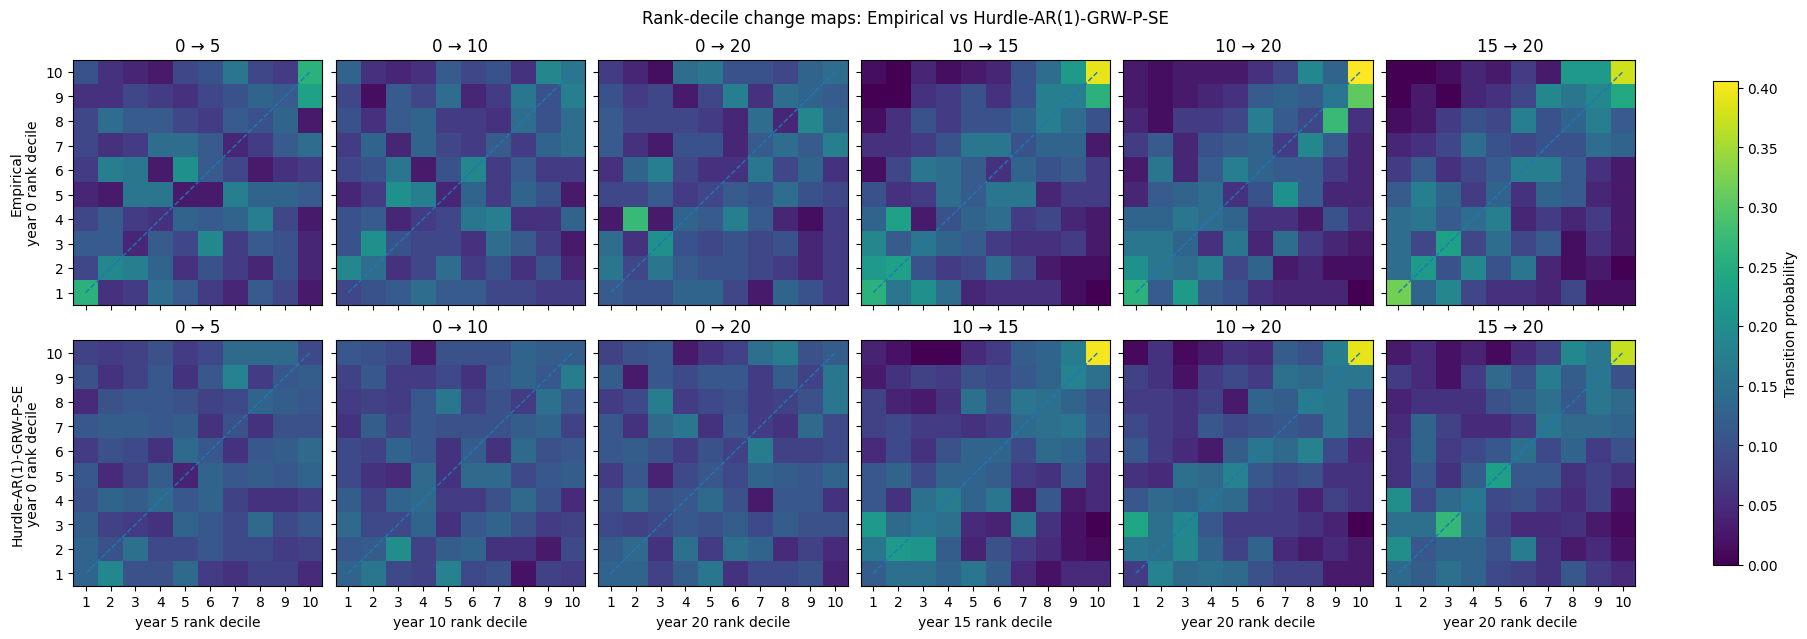

In [34]:

rank_pairs = [(0, 5), (0, 10), (0, 20), (10, 15), (10, 20), (15, 20)]

def orient_trj(A):
    A = np.asarray(A)
    if A.shape[0] == Y + 1:
        return A.T
    if A.shape[1] == Y + 1:
        return A
    raise ValueError(f"bad traj shape {A.shape}")

def rank_deciles(mat, year, n_deciles=10, seed=63):
    x = np.asarray(mat[:, year])
    rng = np.random.default_rng(seed + year)
    tmp = pd.DataFrame({"x": x,"tie": rng.random(len(x)),"idx": np.arange(len(x))})
    tmp = tmp.sort_values(["x", "tie"])
    tmp["decile"] = np.ceil(np.arange(1, len(tmp) + 1) / len(tmp) * n_deciles).astype(int)
    tmp["decile"] = tmp["decile"].clip(1, n_deciles)
    return tmp.sort_values("idx")["decile"].to_numpy()

def decile_change_probs(mat, start, end, n_deciles=10):
    start_decile = rank_deciles(mat, start, n_deciles=n_deciles)
    end_decile = rank_deciles(mat, end, n_deciles=n_deciles)

    counts = pd.crosstab(
        start_decile,
        end_decile,
        rownames=[f"year {start} decile"],
        colnames=[f"year {end} decile"],
        dropna=False)

    counts = counts.reindex(
        index=np.arange(1, n_deciles + 1),
        columns=np.arange(1, n_deciles + 1),
        fill_value=0)

    return counts.div(counts.sum(axis=1), axis=0)

emp_panel_rank = (
    working_df[working_df["CareerAge"].between(0, Y)]
    .pivot_table(index="dblp_id",columns="CareerAge",values="pubs_adj")
    .reindex(columns=np.arange(Y + 1))
    .dropna())

emp_rank_mat = emp_panel_rank.to_numpy()
sim_rank_mat = orient_trj(trajs_combined)

rank_maps = {}
for start, end in rank_pairs:
    rank_maps[("Empirical", start, end)] = decile_change_probs(emp_rank_mat, start, end)
    rank_maps[(MODEL_NAME, start, end)] = decile_change_probs(sim_rank_mat, start, end)

vmax = max(x.to_numpy().max() for x in rank_maps.values())

fig, axes = plt.subplots(2, len(rank_pairs), figsize=(18, 6), sharex=True, sharey=True, constrained_layout=True)

for c, (start, end) in enumerate(rank_pairs):
    for r, label in enumerate(["Empirical", MODEL_NAME]):
        ax = axes[r, c]
        probs = rank_maps[(label, start, end)]

        im = ax.imshow(probs,origin="lower",aspect="auto",vmin=0,vmax=vmax,interpolation="nearest")

        ax.plot(np.arange(10),np.arange(10),linestyle="--",linewidth=1)
        ax.set_title(f"{start} → {end}")

        ax.set_xticks(np.arange(10))
        ax.set_xticklabels(np.arange(1, 11))
        ax.set_yticks(np.arange(10))
        ax.set_yticklabels(np.arange(1, 11))

        if r == 1:
            ax.set_xlabel(f"year {end} rank decile")
        if c == 0:
            ax.set_ylabel(f"{label}\nyear {start} rank decile")

cbar = fig.colorbar(im, ax=axes, shrink=0.92)
cbar.set_label("Transition probability")

fig.suptitle(f"Rank-decile change maps: Empirical vs {MODEL_NAME}", y=1.04)

plt.savefig(FIGURES / f"{MODEL_TAG}_rankDecileChangeMaps.png", dpi=300, bbox_inches="tight")
plt.show()

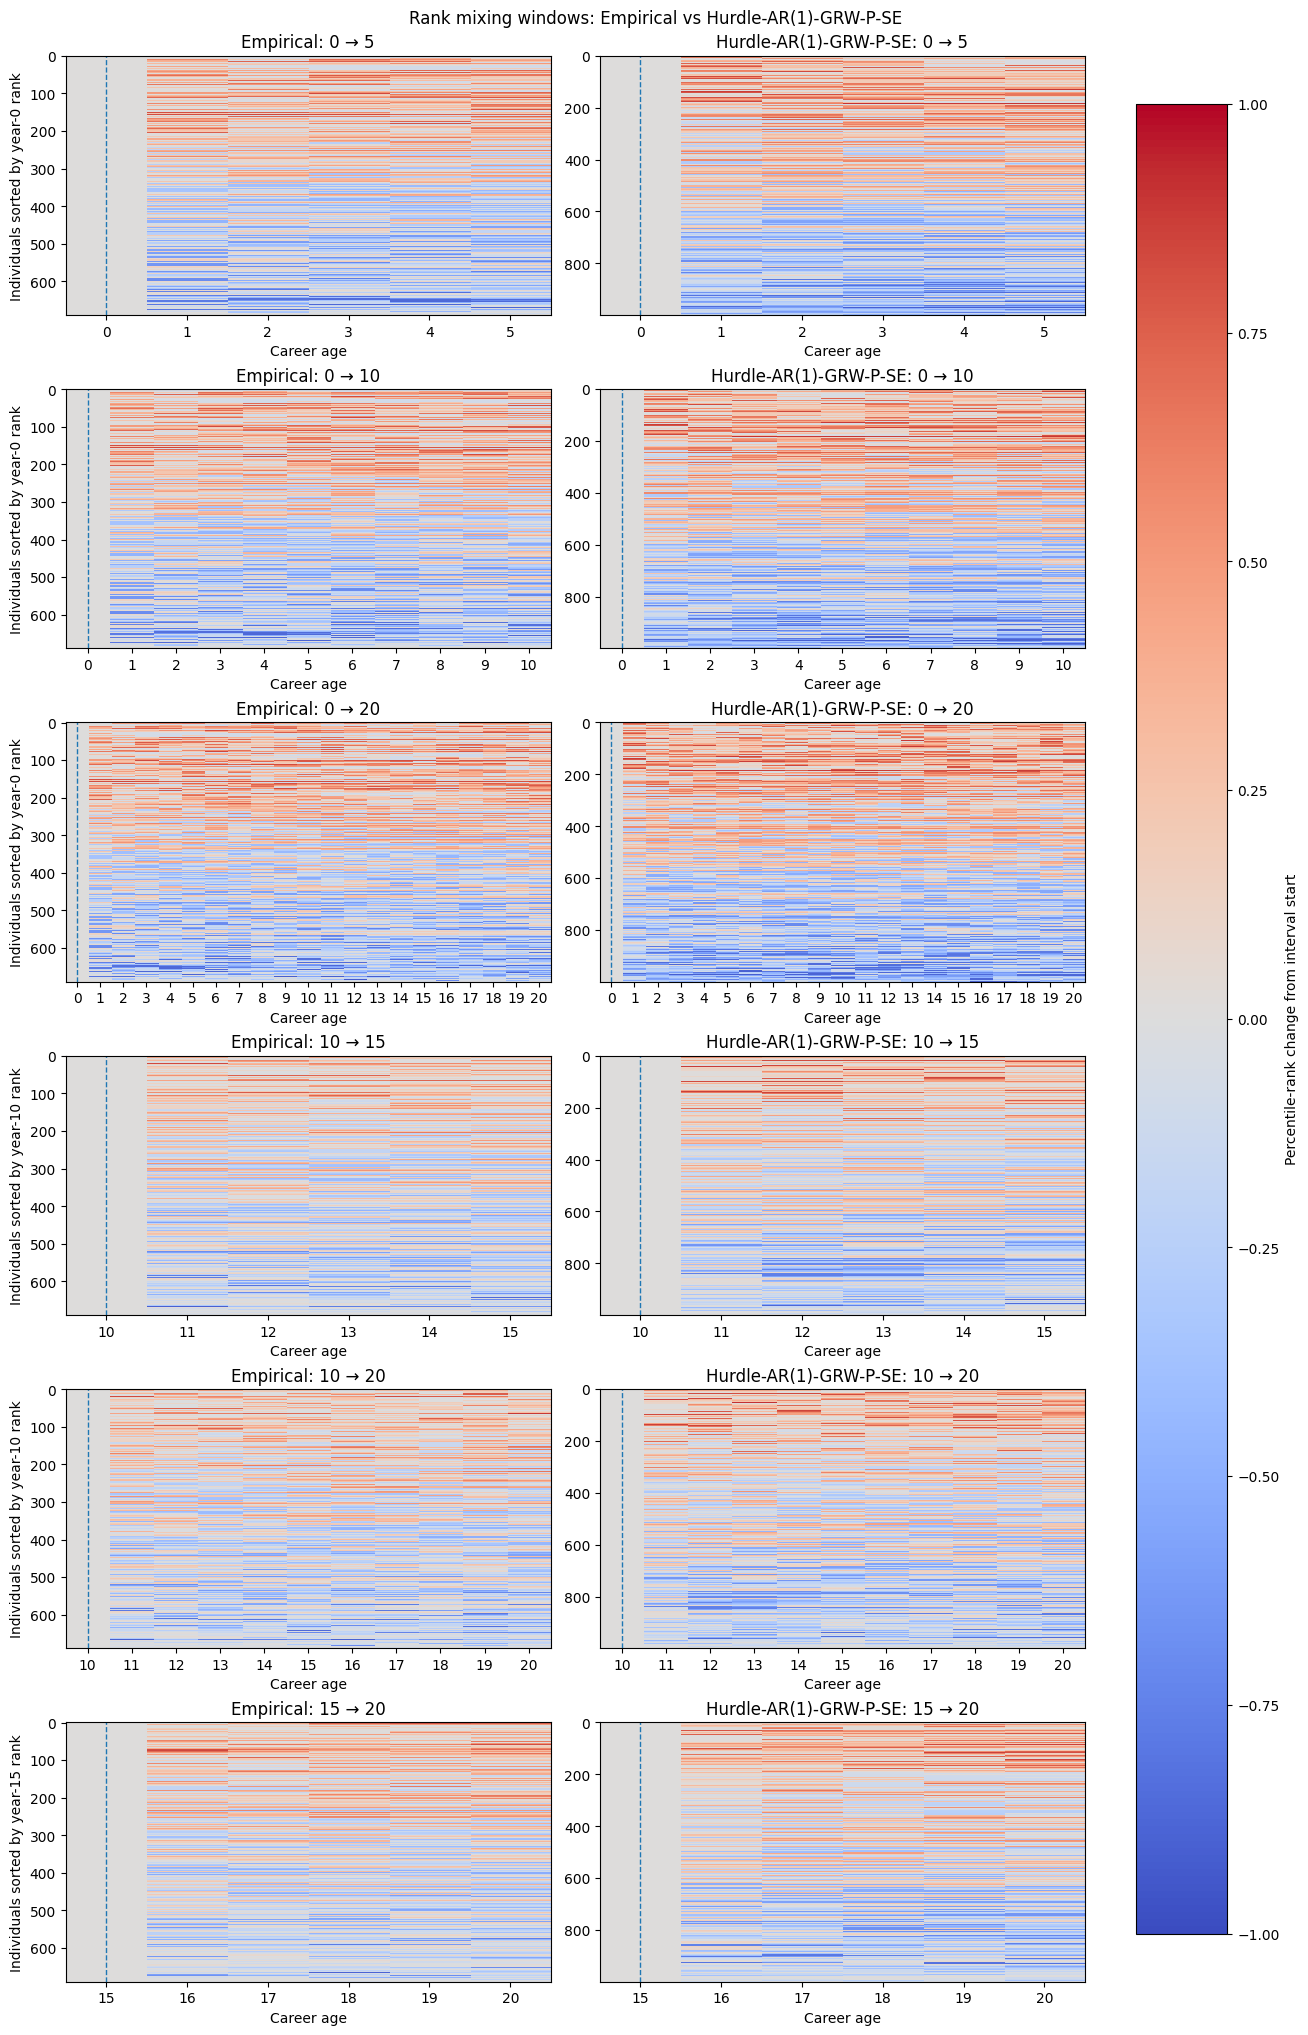

In [35]:
# Cell X: rank-mixing windows

rank_windows = [(0, 5), (0, 10), (0, 20), (10, 15), (10, 20), (15, 20)]

def orient_trj(A):
    A = np.asarray(A)
    return A.T if A.shape[0] == Y + 1 else A

def rank_change_heatmap(mat, start, end):
    years = np.arange(start, end + 1)
    ranks = pd.DataFrame(mat[:, years]).rank(method="average", pct=True).to_numpy()
    delta = ranks - ranks[:, [0]]
    order = np.argsort(ranks[:, 0])
    return delta[order], years

emp_rank_mat = (
    working_df[working_df["CareerAge"].between(0, Y)]
    .pivot_table(index="dblp_id", columns="CareerAge", values="pubs_adj")
    .reindex(columns=np.arange(Y + 1))
    .dropna()
    .to_numpy()
)

sim_rank_mat = orient_trj(trajs_combined)

fig, axes = plt.subplots(len(rank_windows), 2, figsize=(13, 20), constrained_layout=True)

vmin, vmax = -1.0, 1.0

for r, (start, end) in enumerate(rank_windows):
    for c, (label, mat) in enumerate([("Empirical", emp_rank_mat), (MODEL_NAME, sim_rank_mat)]):
        delta, years = rank_change_heatmap(mat, start, end)

        im = axes[r, c].imshow(delta, aspect="auto", cmap="coolwarm", vmin=vmin, vmax=vmax, interpolation="nearest")

        axes[r, c].set_title(f"{label}: {start} → {end}")
        axes[r, c].set_xlabel("Career age")
        axes[r, c].set_xticks(np.arange(len(years)))
        axes[r, c].set_xticklabels(years)
        axes[r, c].axvline(0, linestyle="--", linewidth=1)

        if c == 0:
            axes[r, c].set_ylabel(f"Individuals sorted by year-{start} rank")

cbar = fig.colorbar(im, ax=axes, shrink=0.95)
cbar.set_label("Percentile-rank change from interval start")

fig.suptitle(f"Rank mixing windows: Empirical vs {MODEL_NAME}", y=1.01)

plt.savefig(FIGURES / f"{MODEL_TAG}_rank_mixing_windows.png", dpi=300, bbox_inches="tight")
plt.show()

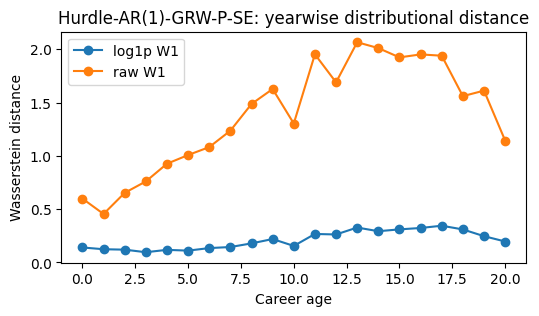

In [37]:
from scipy.stats import wasserstein_distance

dist_rows = []
for y in range(Y + 1):
    emp_y = emp_panel_full[y].dropna().to_numpy()
    sim_y = trajs_combined[y, :]
    dist_rows.append({
        "CareerAge": y,
        "W1_log1p": wasserstein_distance(np.log1p(emp_y), np.log1p(sim_y)),
        "W1_raw": wasserstein_distance(emp_y, sim_y)
    })

dist_df = pd.DataFrame(dist_rows)

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(dist_df["CareerAge"], dist_df["W1_log1p"], marker="o", label="log1p W1")
ax.plot(dist_df["CareerAge"], dist_df["W1_raw"], marker="o", label="raw W1")
ax.set_xlabel("Career age")
ax.set_ylabel("Wasserstein distance")
ax.set_title(f"{MODEL_NAME}: yearwise distributional distance")
ax.legend()
plt.show()

In [38]:
def gini(x):
    x = np.sort(np.asarray(x))
    x = x[np.isfinite(x)]
    if len(x) == 0 or x.sum() == 0:
        return np.nan
    n = len(x)
    return (2 * np.sum(np.arange(1, n + 1) * x) / (n * x.sum())) - ((n + 1) / n)

cum_emp = emp_panel_full.loc[:, 0:Y].sum(axis=1).to_numpy()
cum_sim = trajs_combined[:Y + 1, :].sum(axis=0)

print(f"Empirical cumulative Gini: {gini(cum_emp):.3f}")
print(f"Sim cumulative Gini:       {gini(cum_sim):.3f}")

Empirical cumulative Gini: 0.370
Sim cumulative Gini:       0.397


In [39]:
def top_share(x, frac=0.1):
    x = np.asarray(x)
    x = x[np.isfinite(x)]
    if x.sum() == 0:
        return np.nan
    cutoff = np.quantile(x, 1 - frac)
    return x[x >= cutoff].sum() / x.sum()

cum_emp = emp_panel_full.loc[:, 0:Y].sum(axis=1).to_numpy()
cum_sim = trajs_combined[:Y + 1, :].sum(axis=0)

print(f"Emp top 10% cumulative share: {top_share(cum_emp, 0.10):.3f}")
print(f"Sim top 10% cumulative share: {top_share(cum_sim, 0.10):.3f}")
print()
print(f"Emp top 5% cumulative share:  {top_share(cum_emp, 0.05):.3f}")
print(f"Sim top 5% cumulative share:  {top_share(cum_sim, 0.05):.3f}")
print()
print(f"Emp top 1% cumulative share:  {top_share(cum_emp, 0.01):.3f}")
print(f"Sim top 1% cumulative share:  {top_share(cum_sim, 0.01):.3f}")

Emp top 10% cumulative share: 0.265
Sim top 10% cumulative share: 0.288

Emp top 5% cumulative share:  0.160
Sim top 5% cumulative share:  0.176

Emp top 1% cumulative share:  0.042
Sim top 1% cumulative share:  0.054
